In [1]:
%env JAX_PLATFORM_NAME=cpu
%env CUDA_VISIBLE_DEVICES=None
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
%env JAX_ENABLE_X64=True
import jax
try:
    jax.devices()
except:
    jax.devices()

env: JAX_PLATFORM_NAME=cpu
env: CUDA_VISIBLE_DEVICES=None
env: XLA_PYTHON_CLIENT_PREALLOCATE=false
env: JAX_ENABLE_X64=True


2024-12-17 07:01:28.526159: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [2]:
import p3o
from utils import *

# Load Run

In [3]:
run_name = "cascade_quadratic_reward"
trainer = p3o.Trainer.load_from(run_name)
nnx.display(trainer)

# Null Policy

Mean return: -17.355123591987546 +- 10.524517518124506
Mean cost: 0.014017971805760117 +- 0.006097963563760319


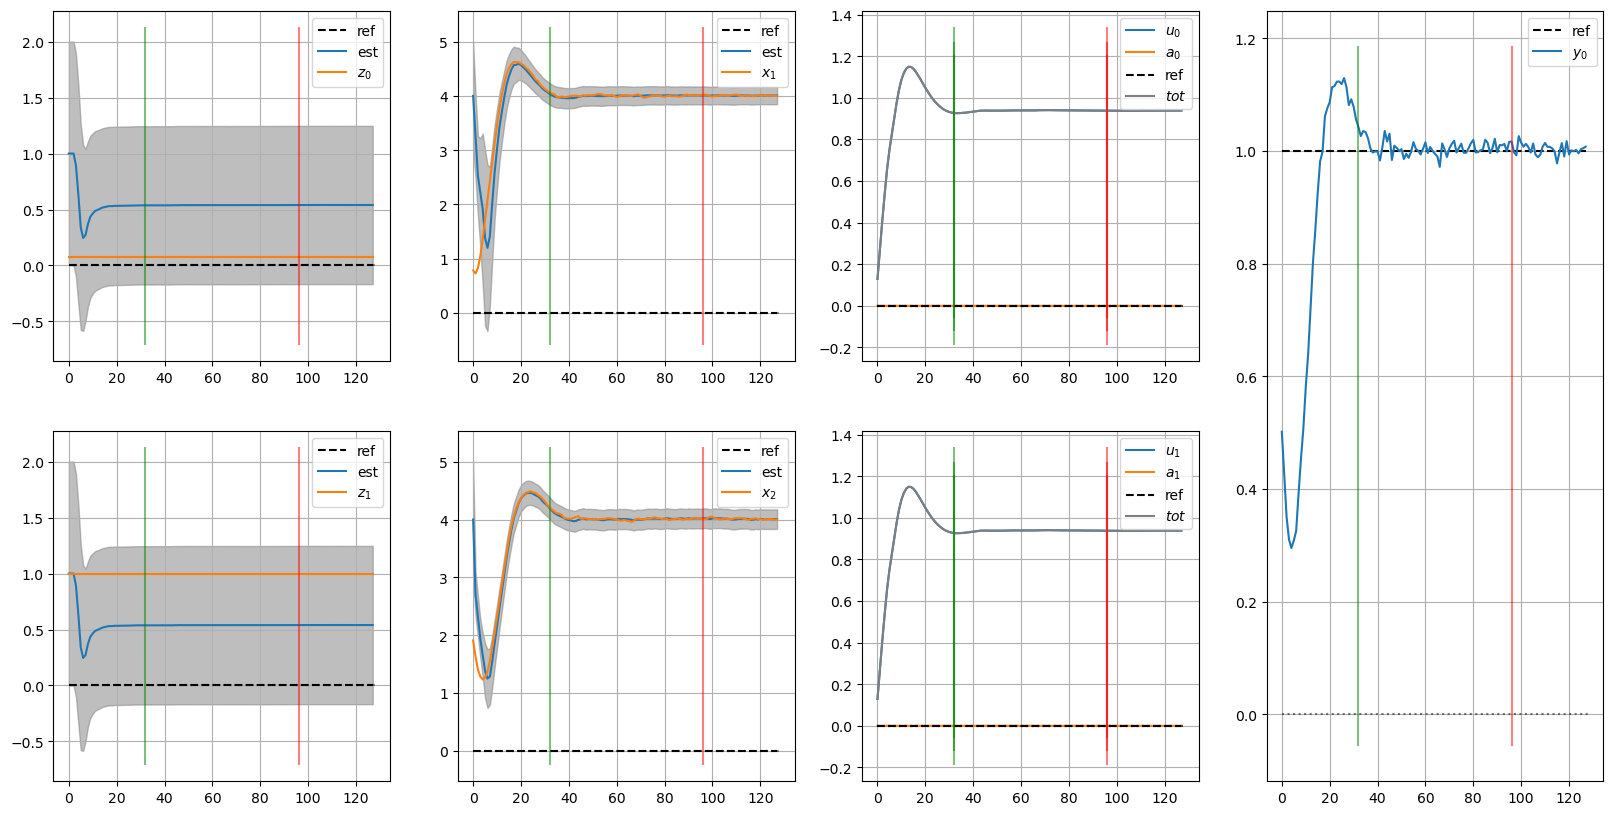

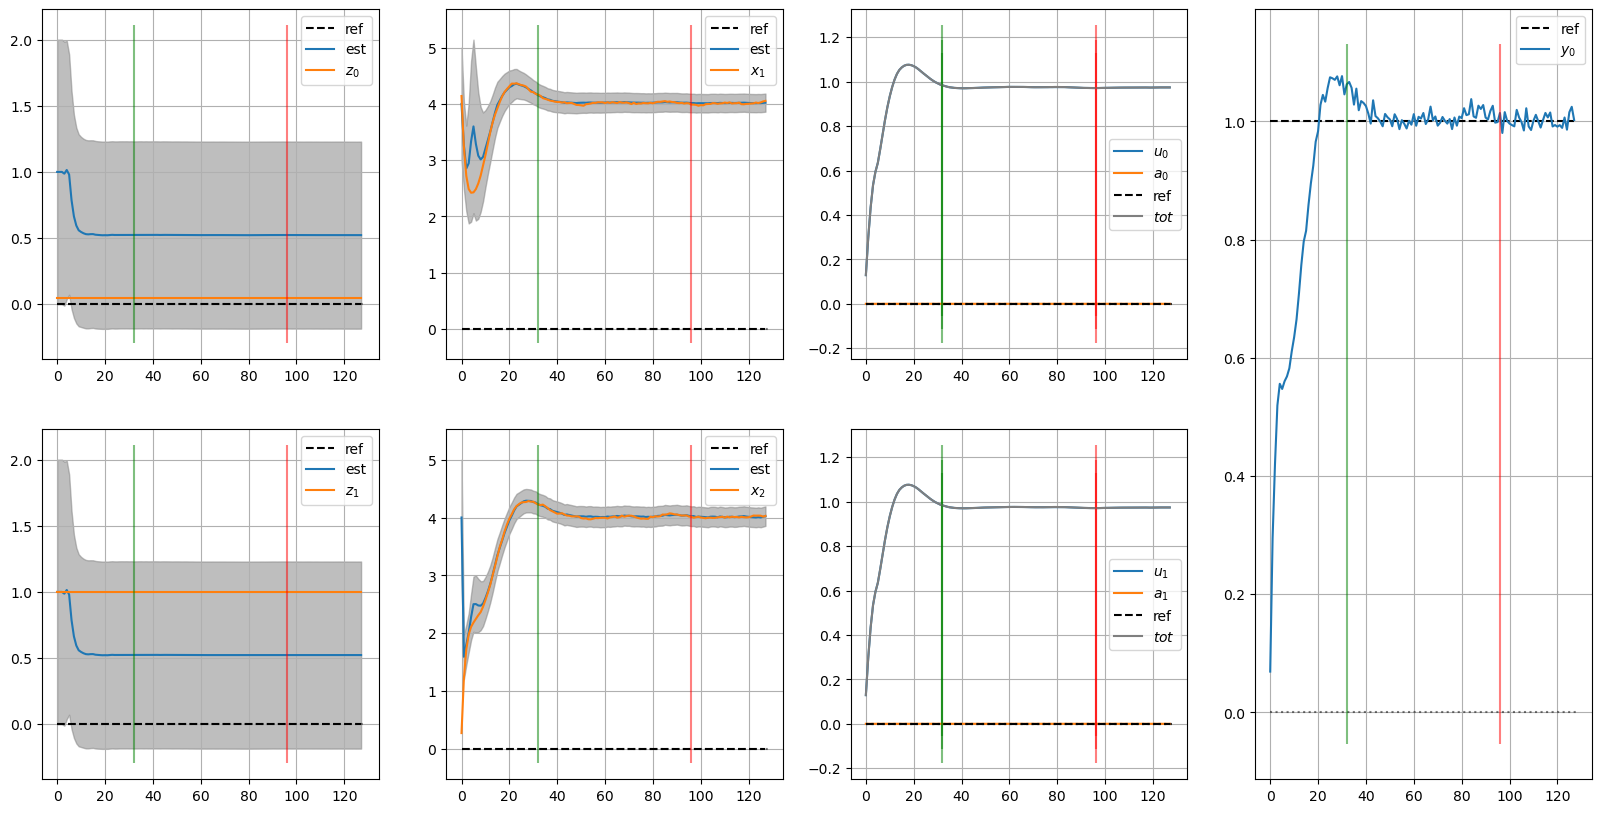

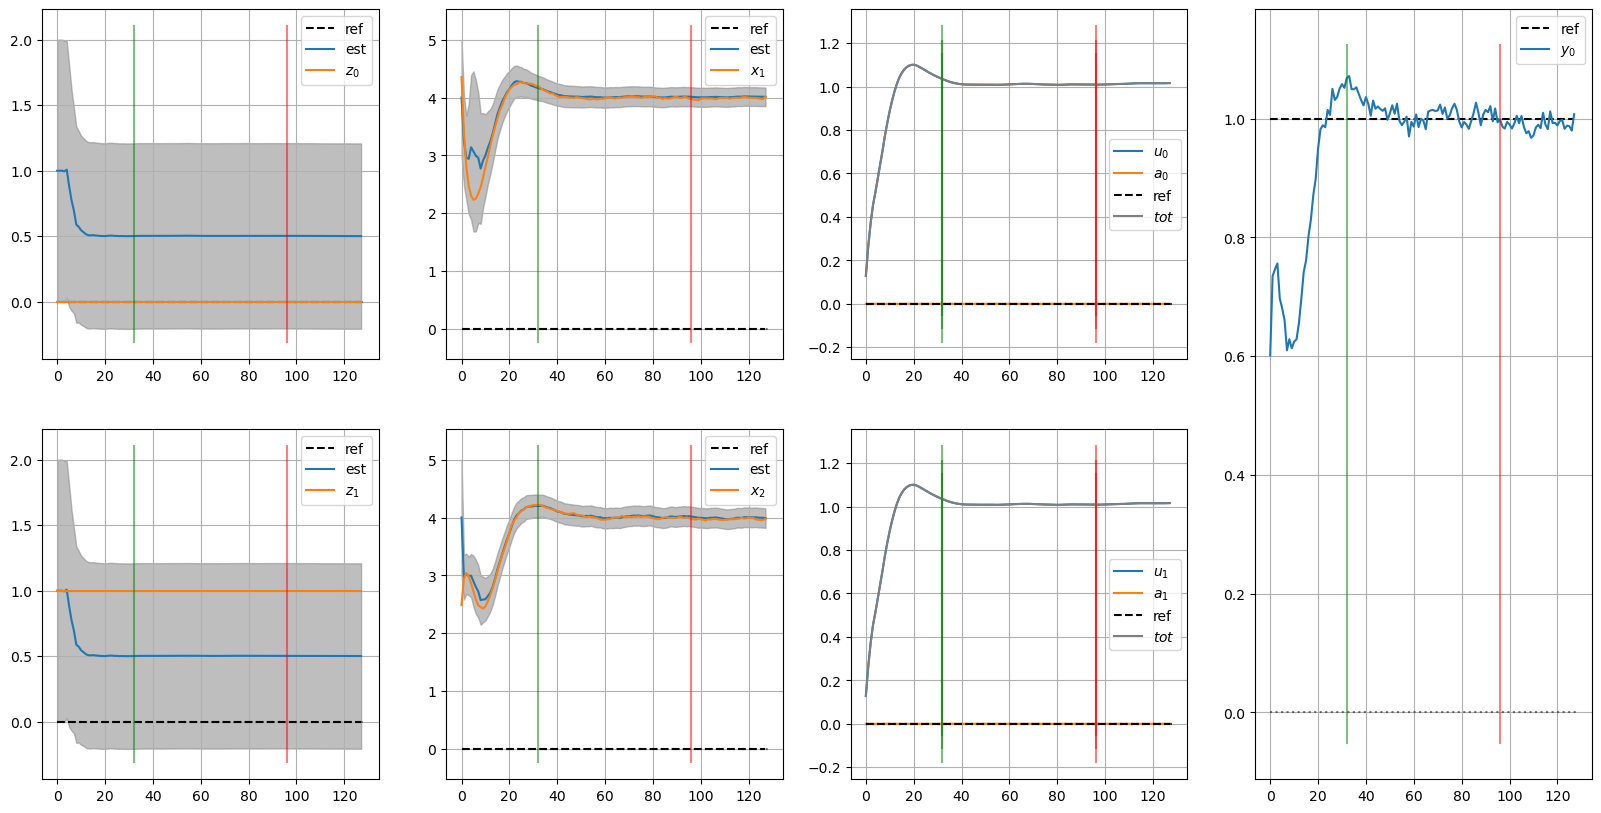

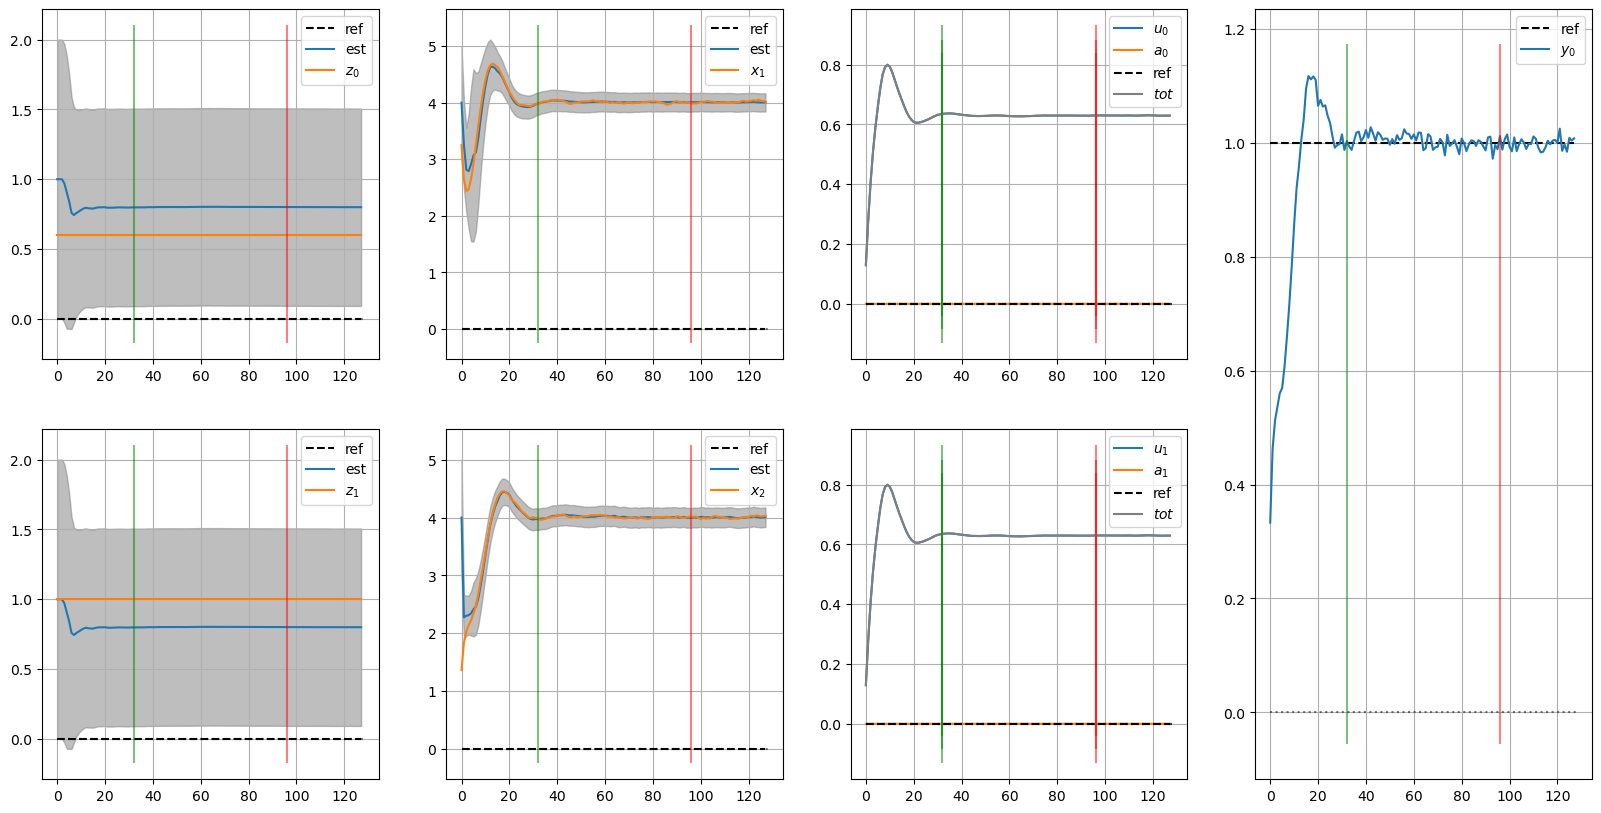

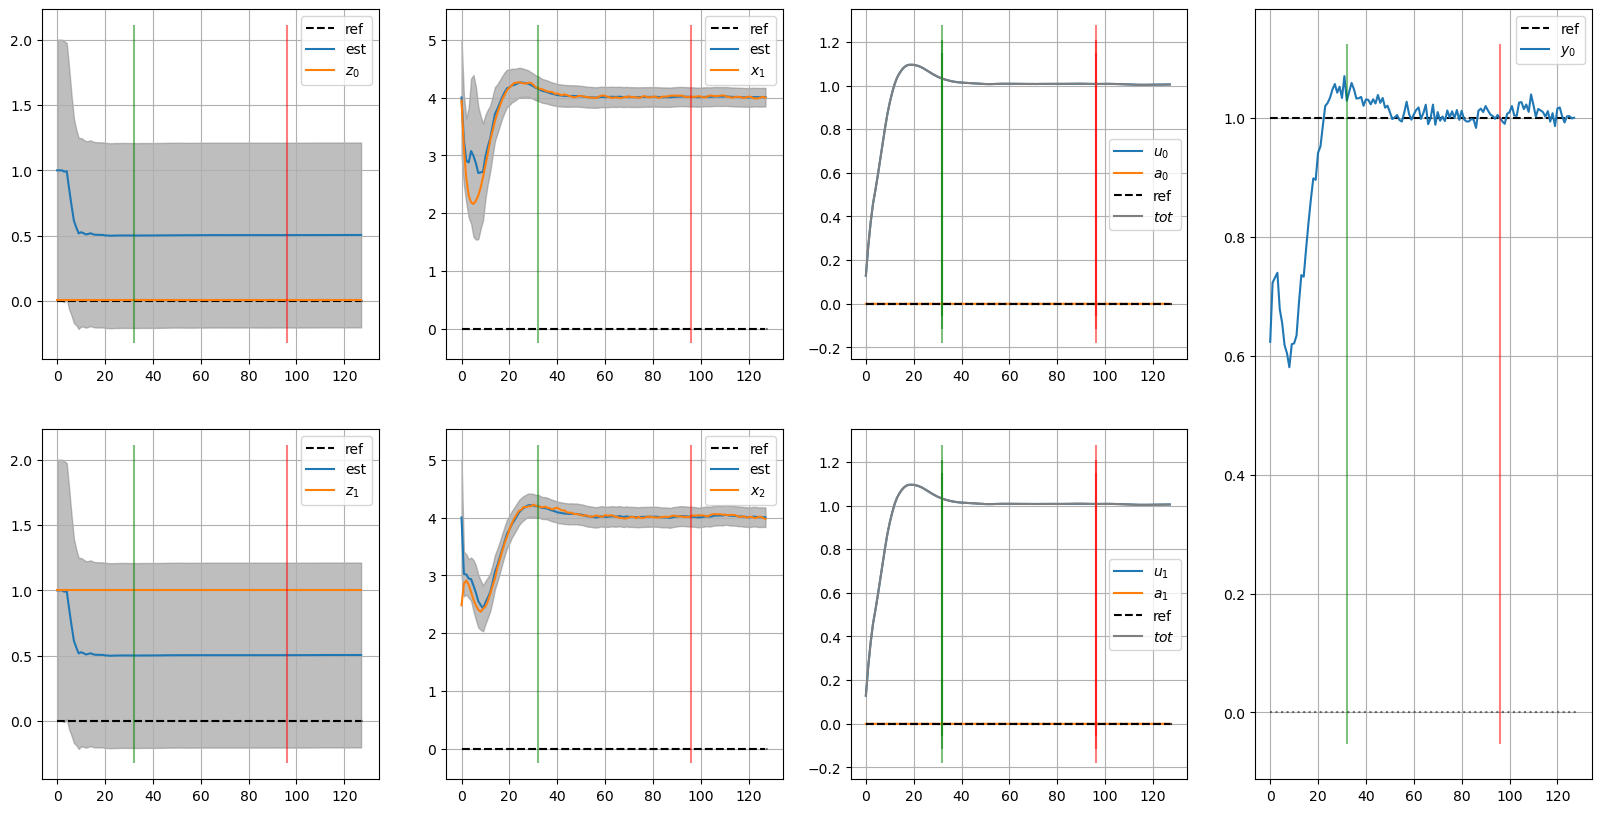

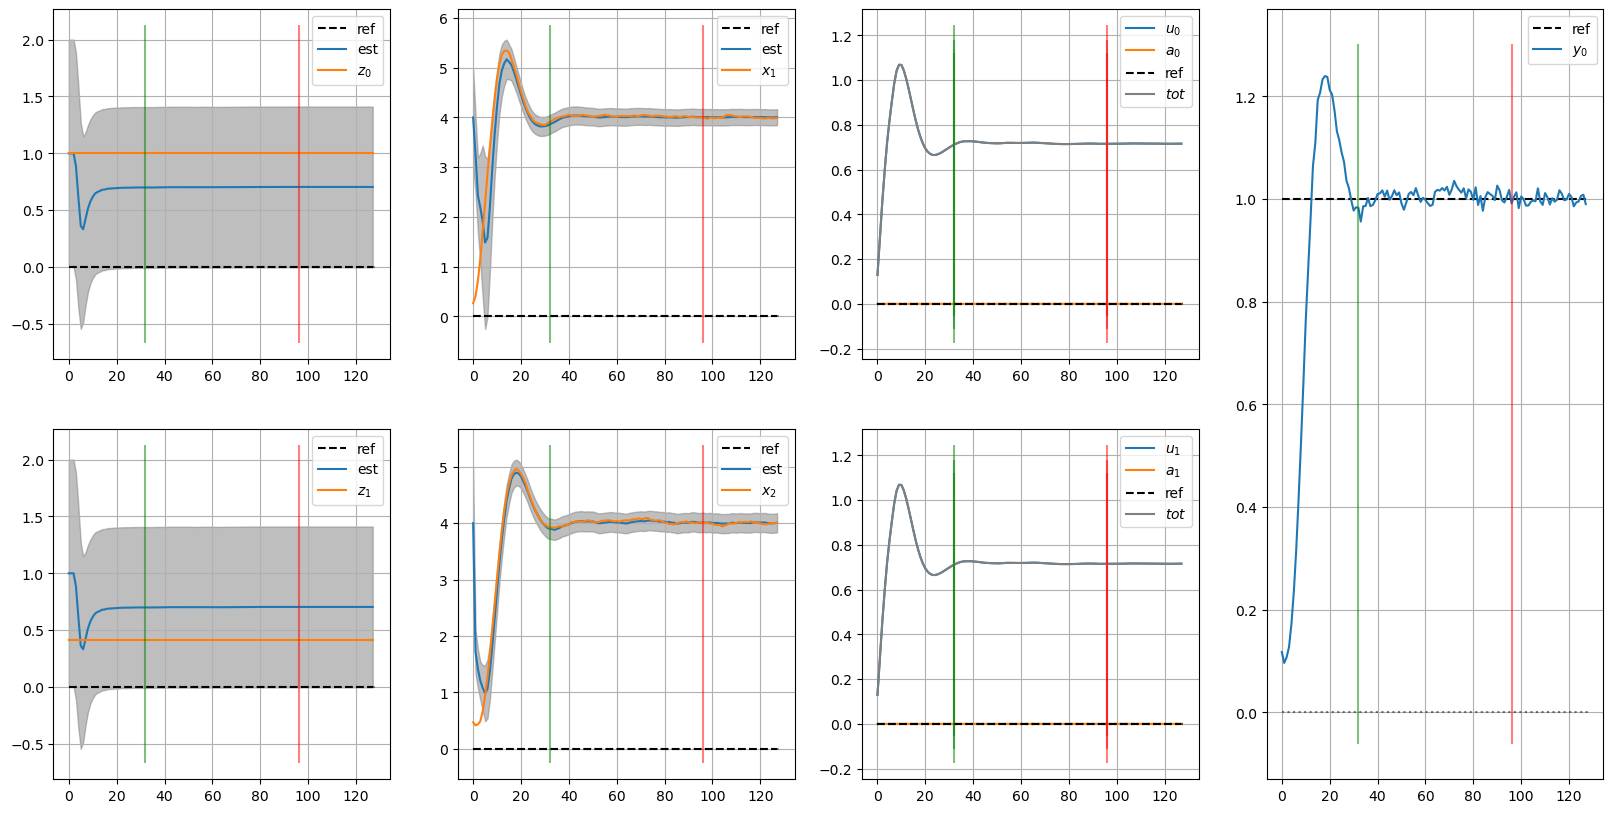

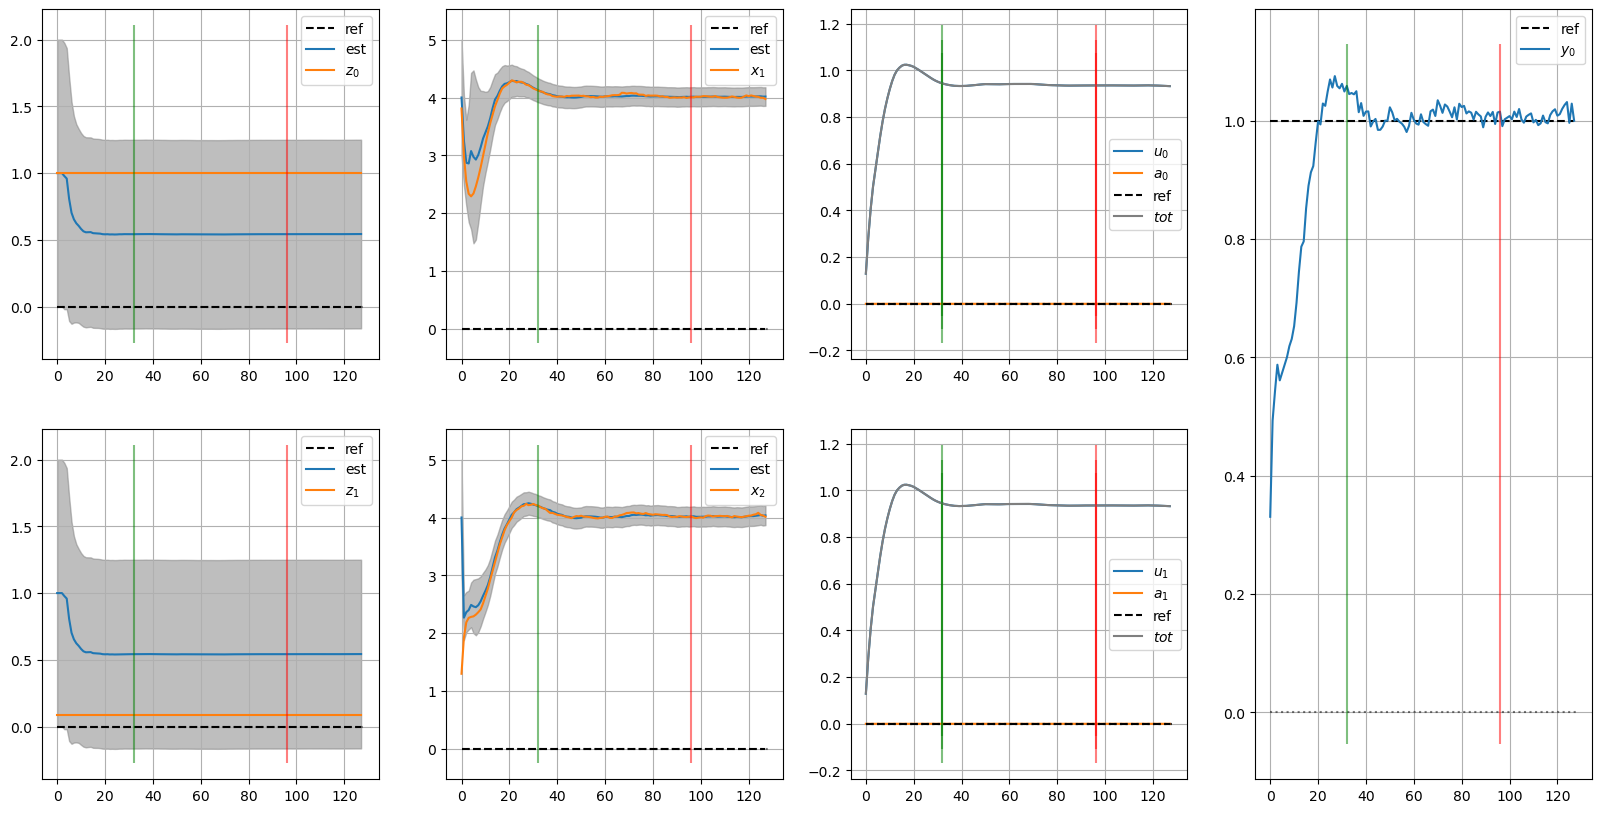

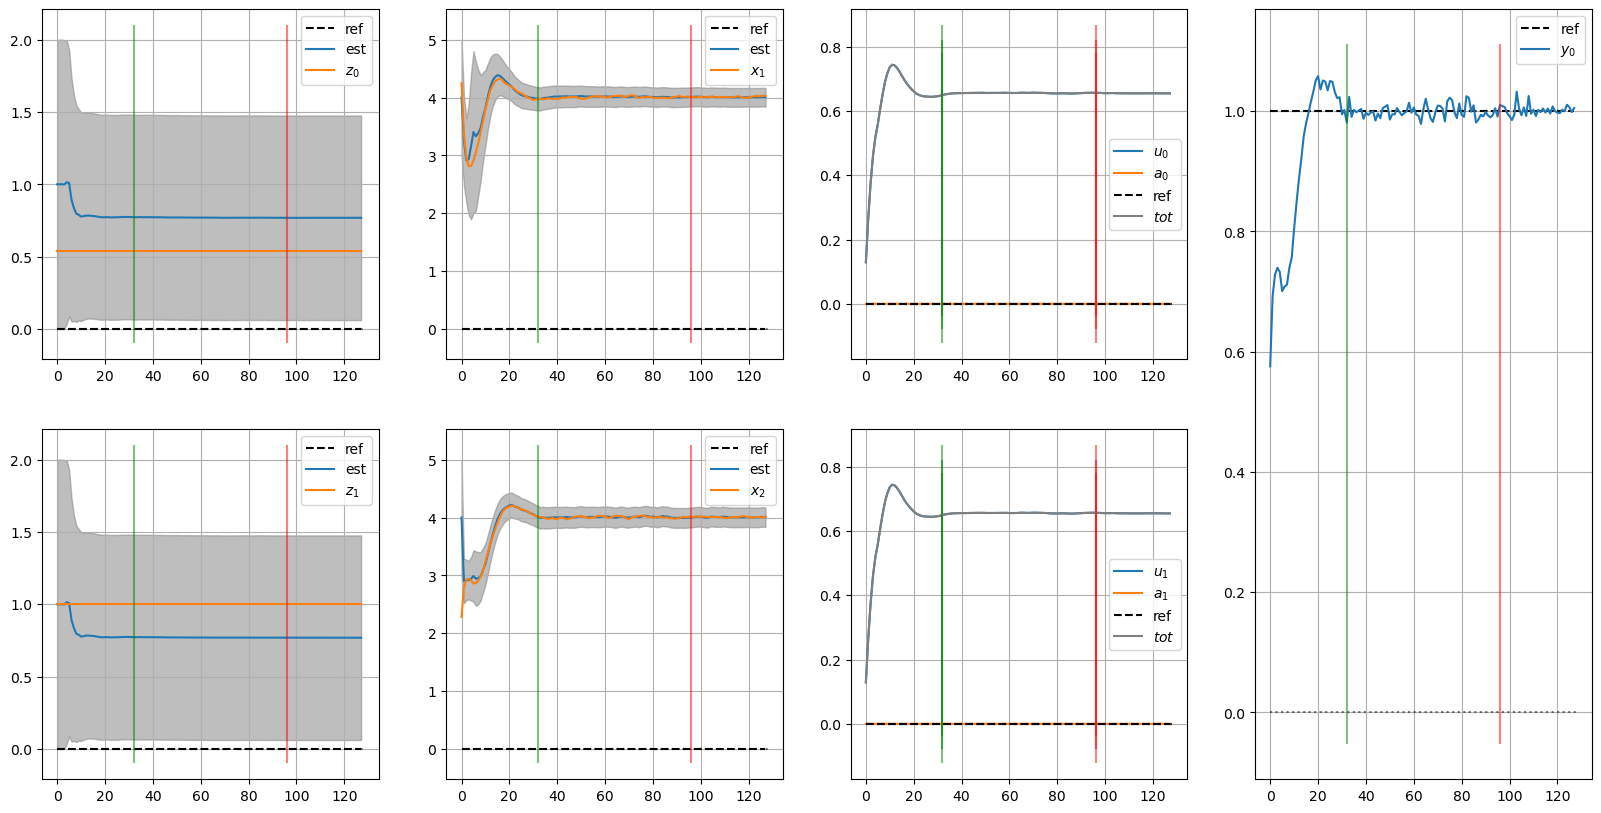

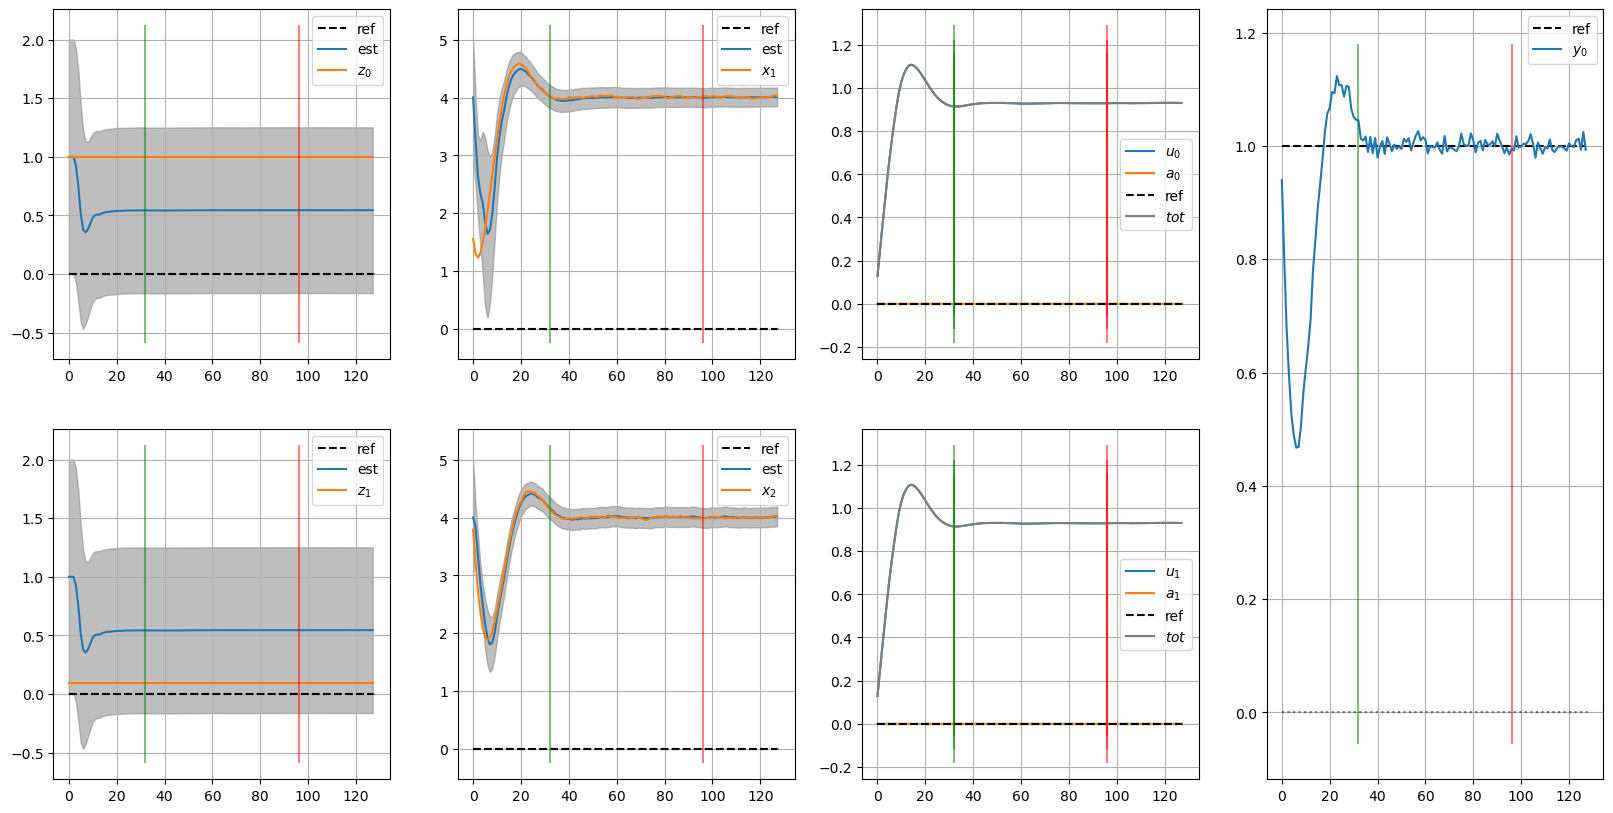

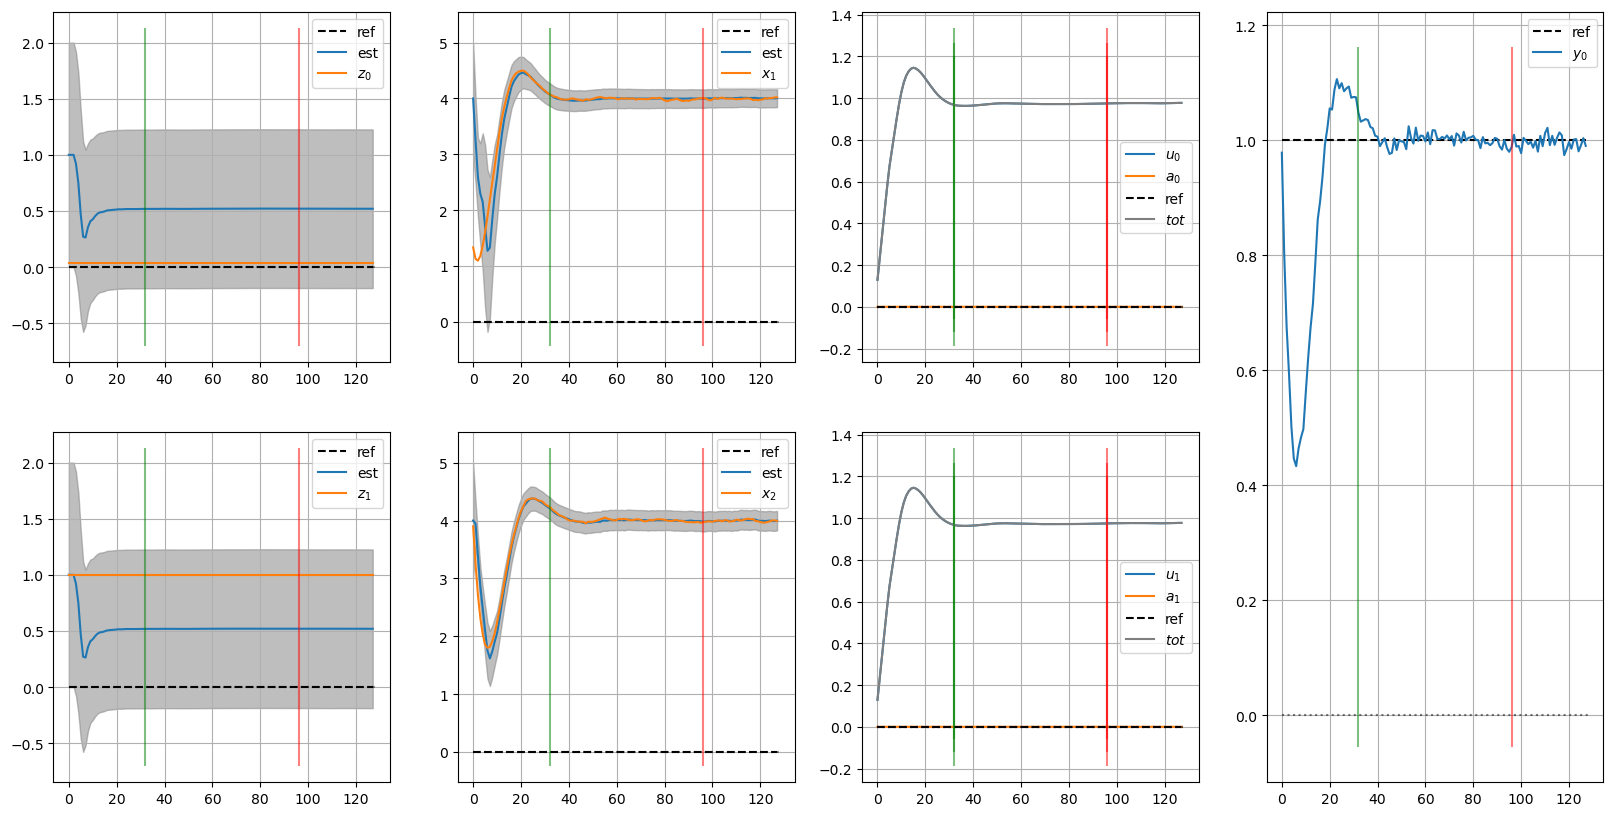

In [4]:
policy = nnx.clone(trainer.untrained_policy)
policy.std *= 1e-20

costs, rewards = [], []
for i in range(100):
    rollout, out = trainer.env.rollout(policy)    
    R = get_returns(rollout.r, trainer.discount)[0]
    C = get_returns(rollout.c, trainer.discount)[0]
    costs.append(C)
    rewards.append(R)
costs, rewards = jnp.array(costs), jnp.array(rewards)
print(f"Mean return: {jnp.mean(rewards)} +- {jnp.std(rewards)}")
print(f"Mean cost: {jnp.mean(costs)} +- {jnp.std(costs)}")

for i in range(10):
    rollout, out = trainer.env.rollout(policy)    
    trainer.env.render(out)

# Untrained Policy

Mean return: -6.585449671374304 +- 4.5230462955345345
Mean cost: 1.5012926524807426 +- 0.2145449961323649


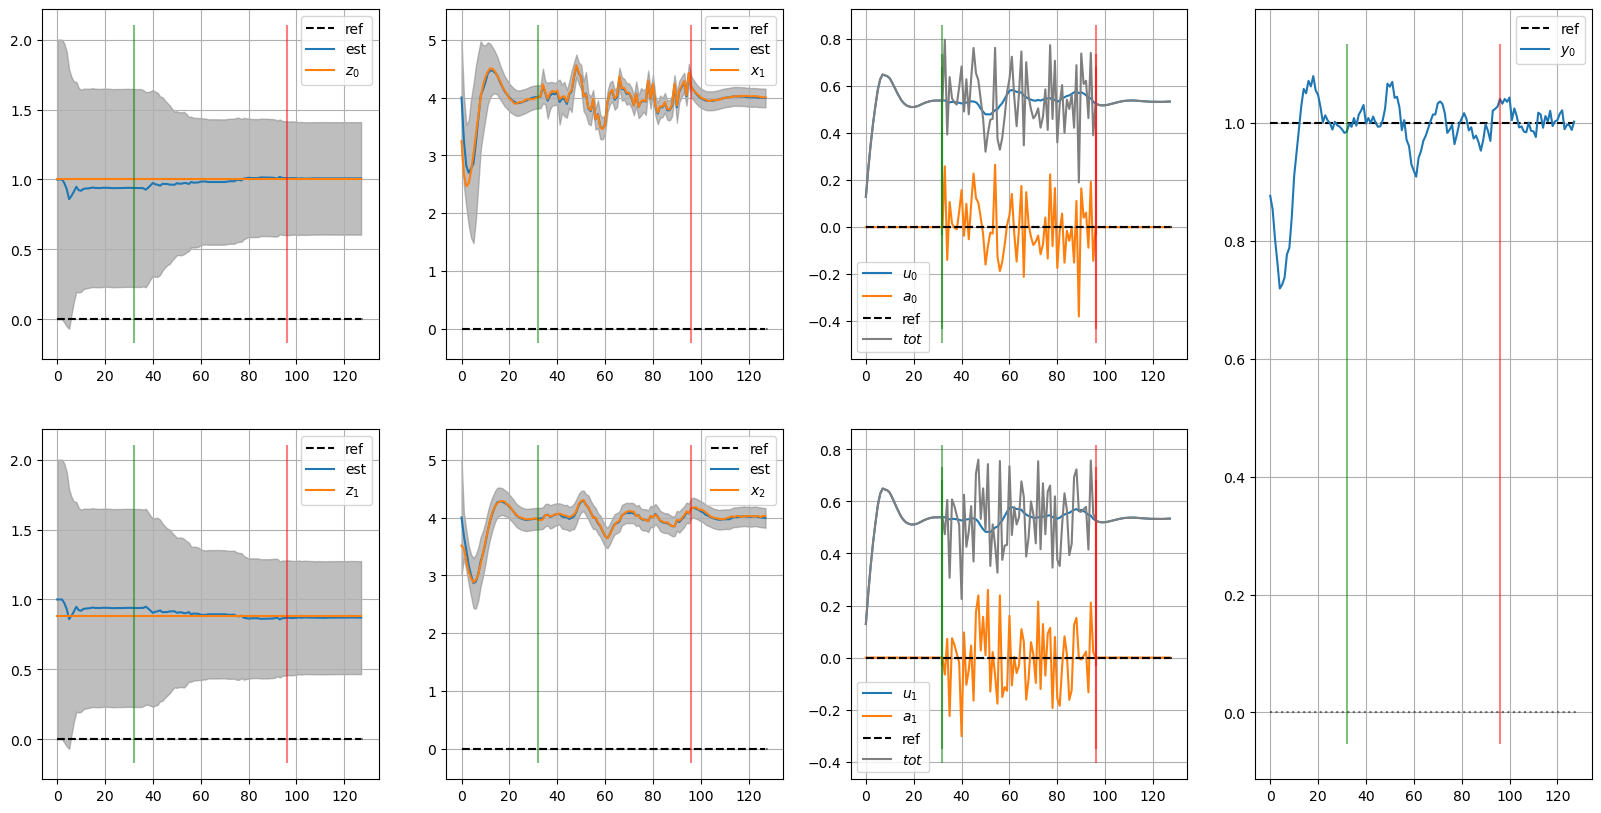

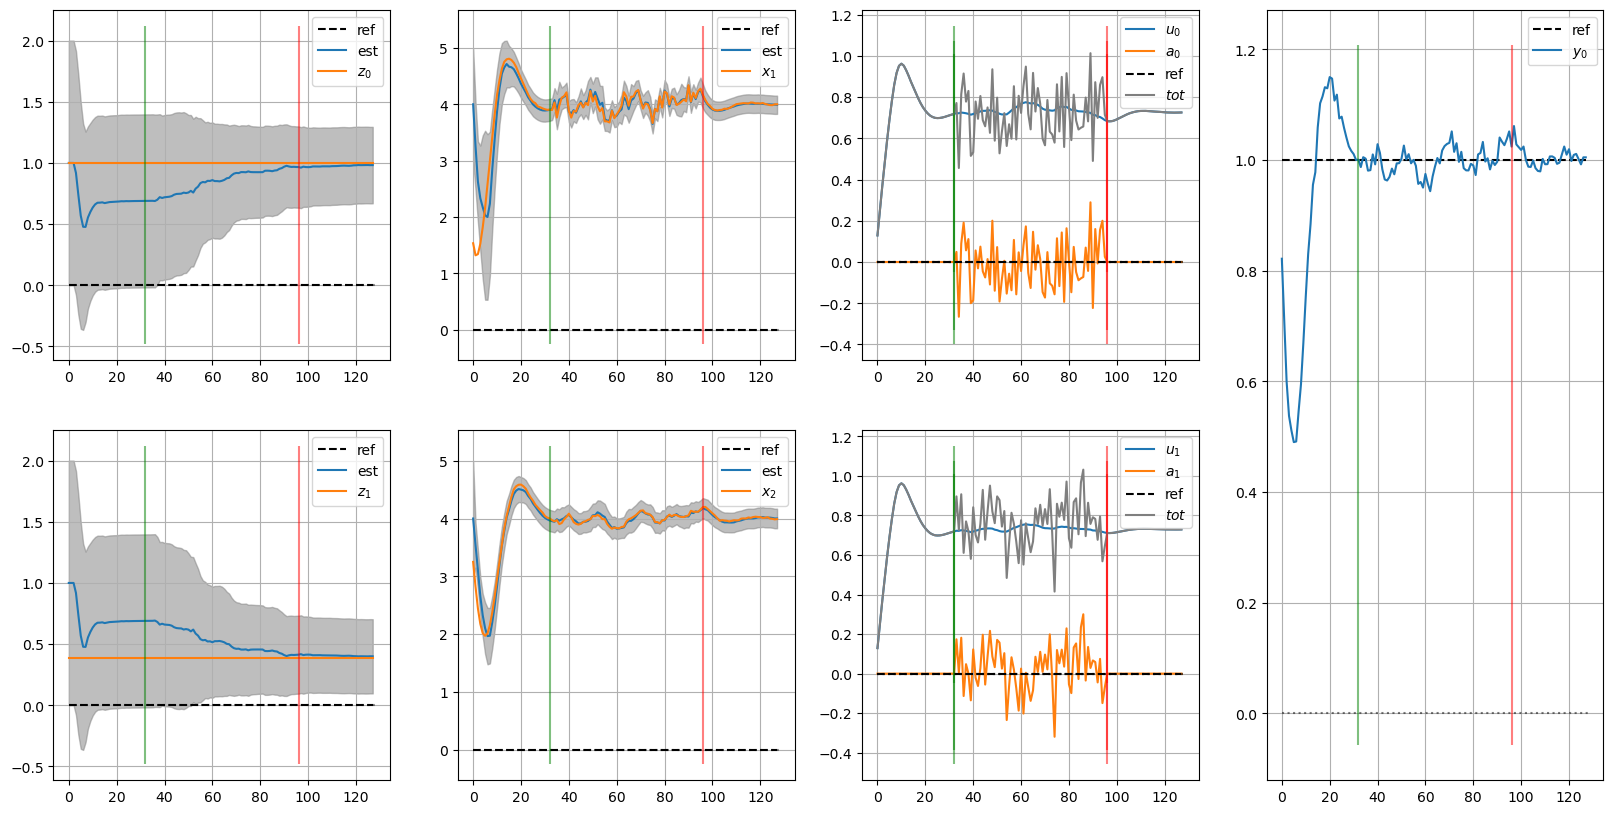

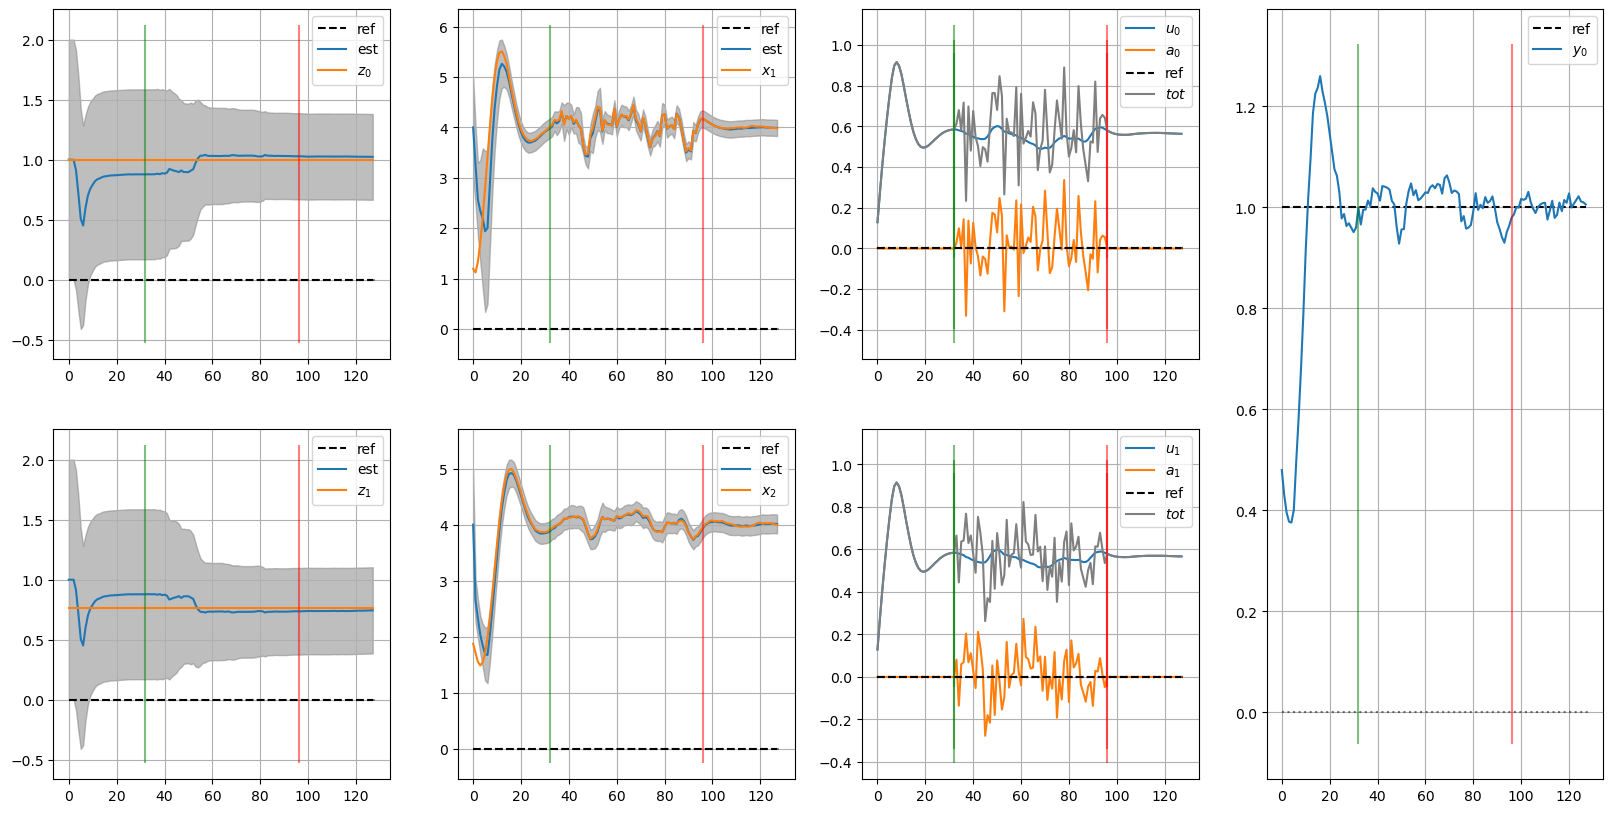

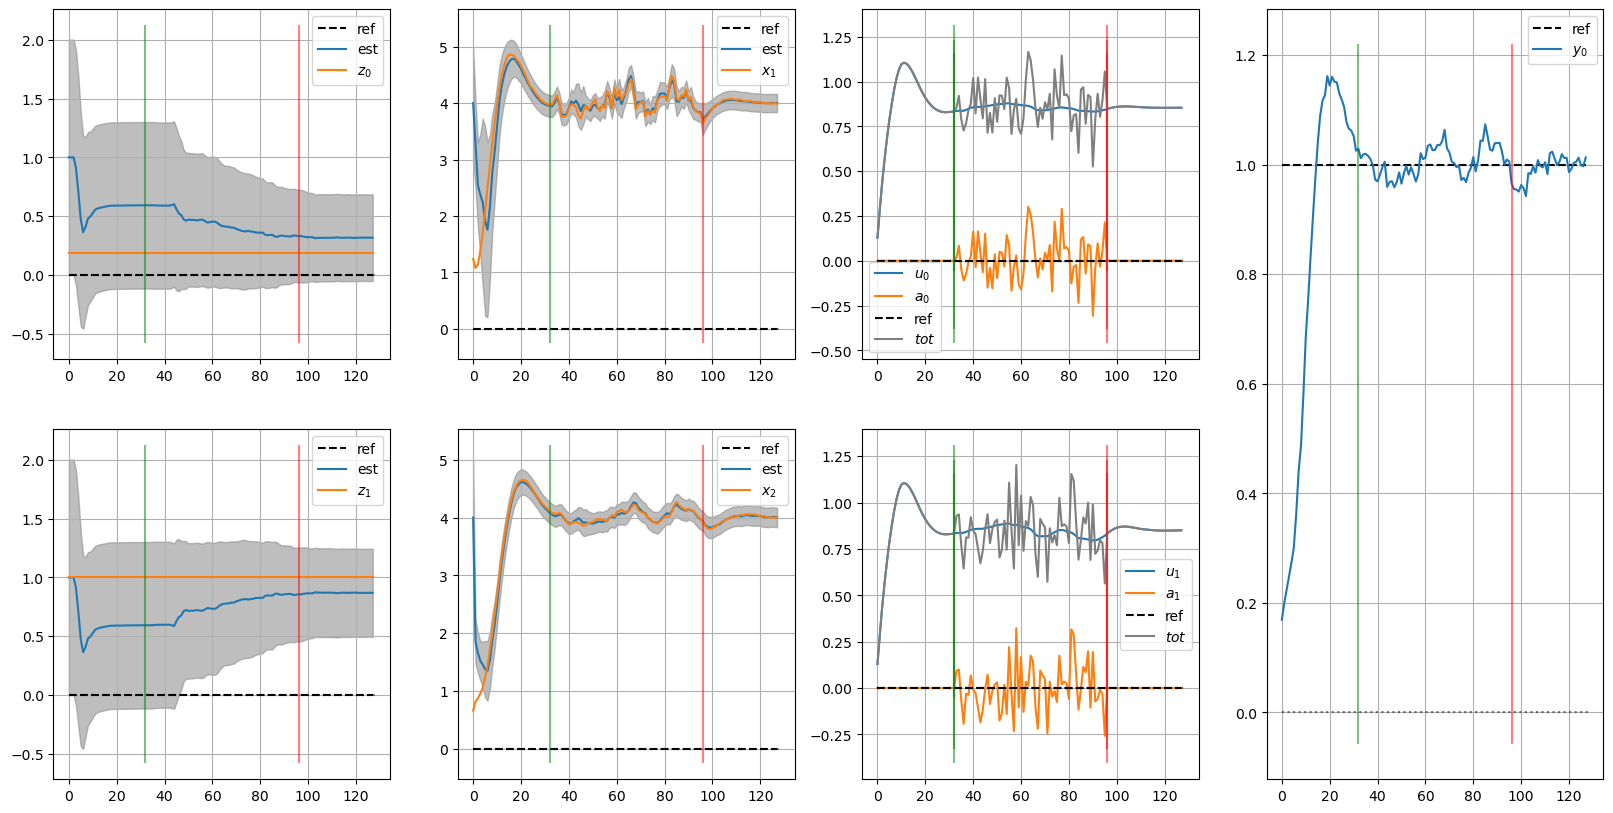

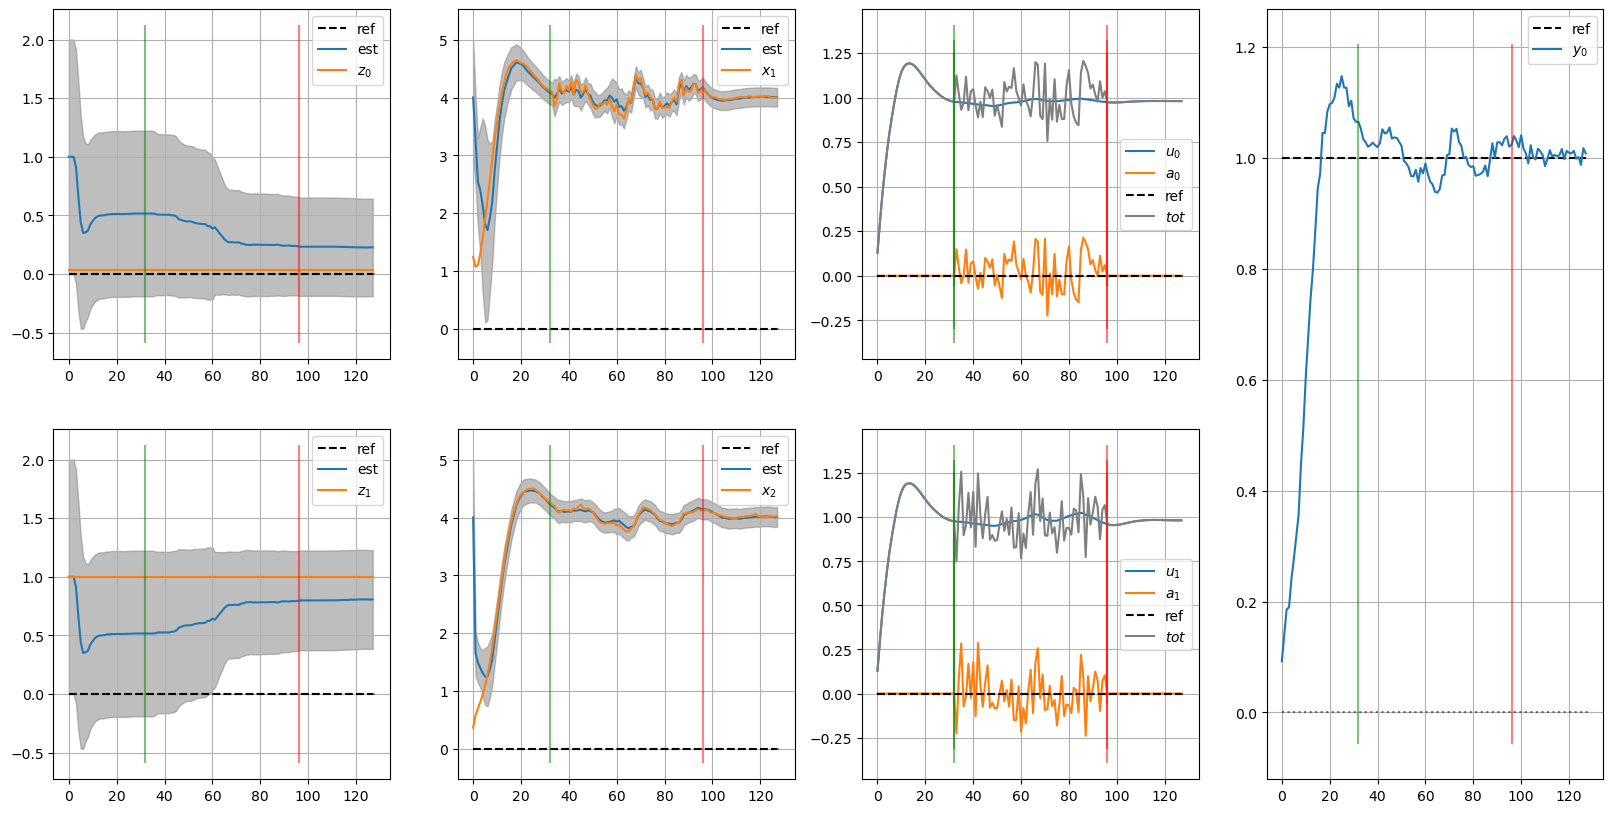

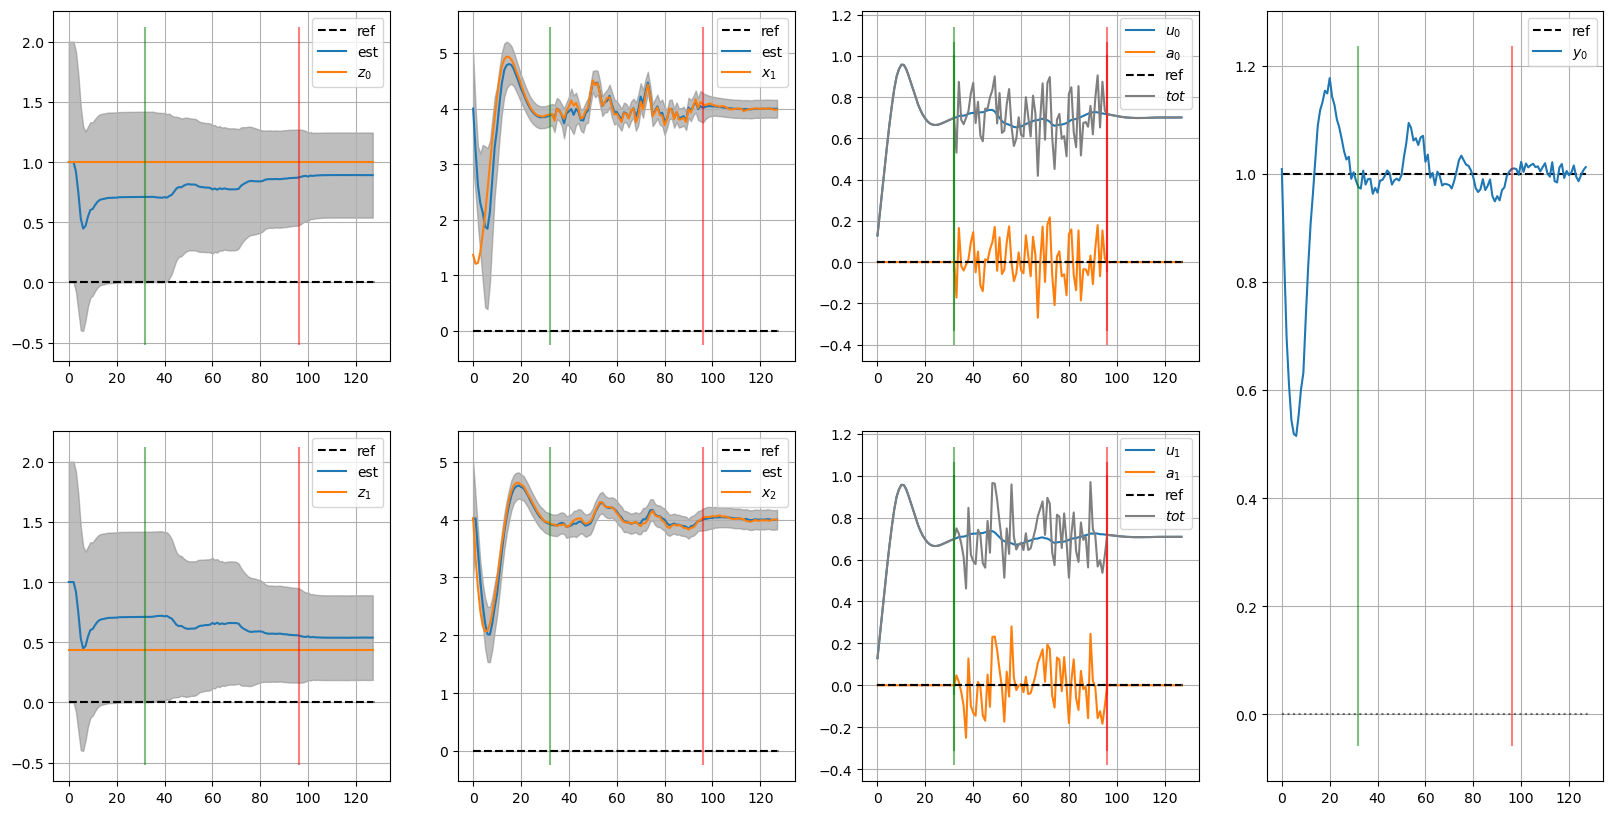

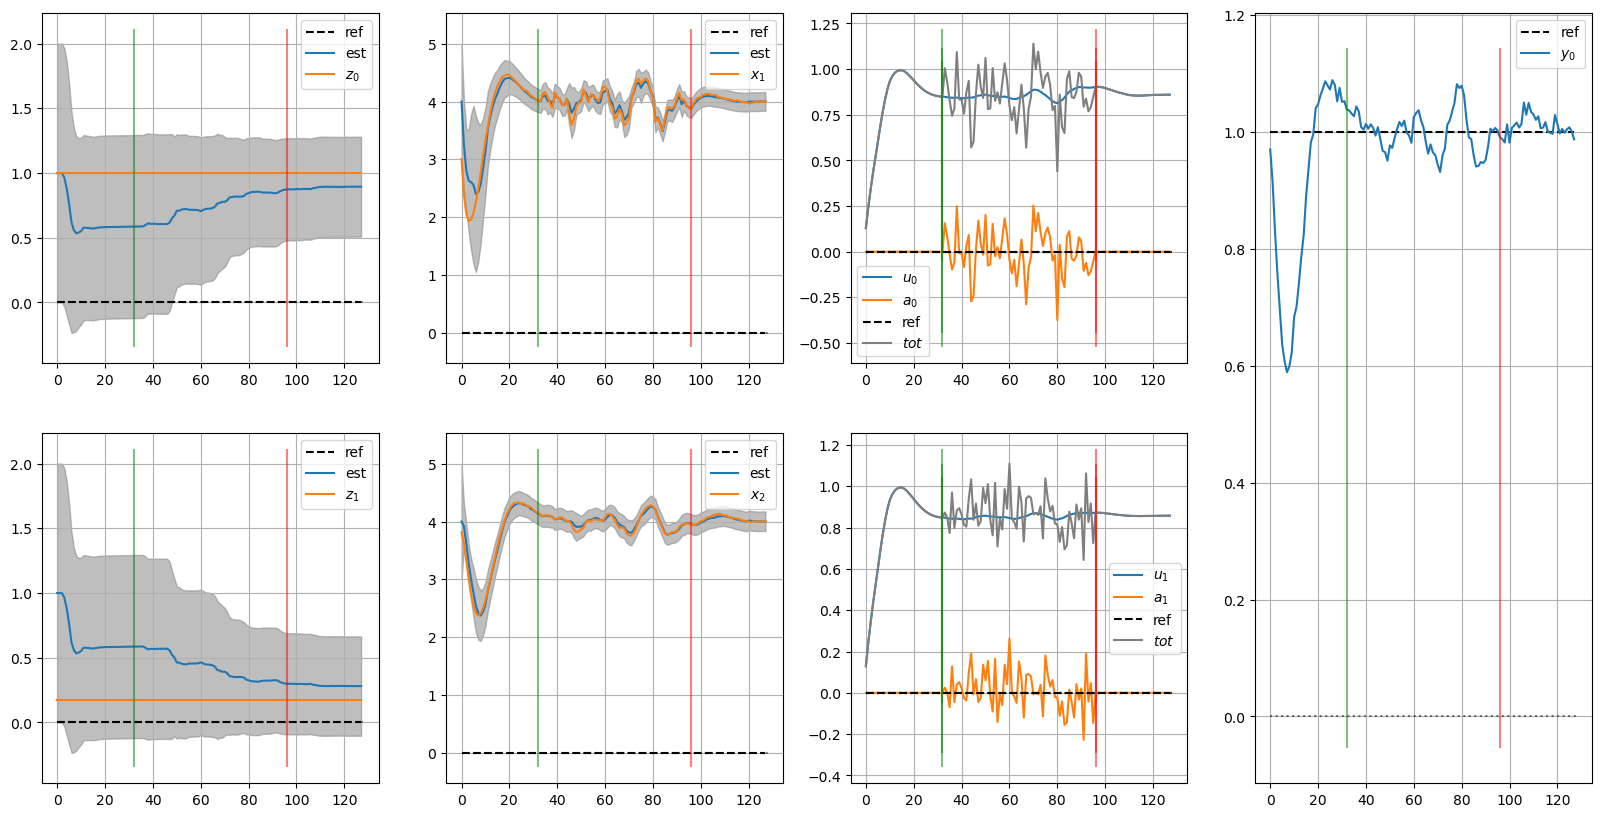

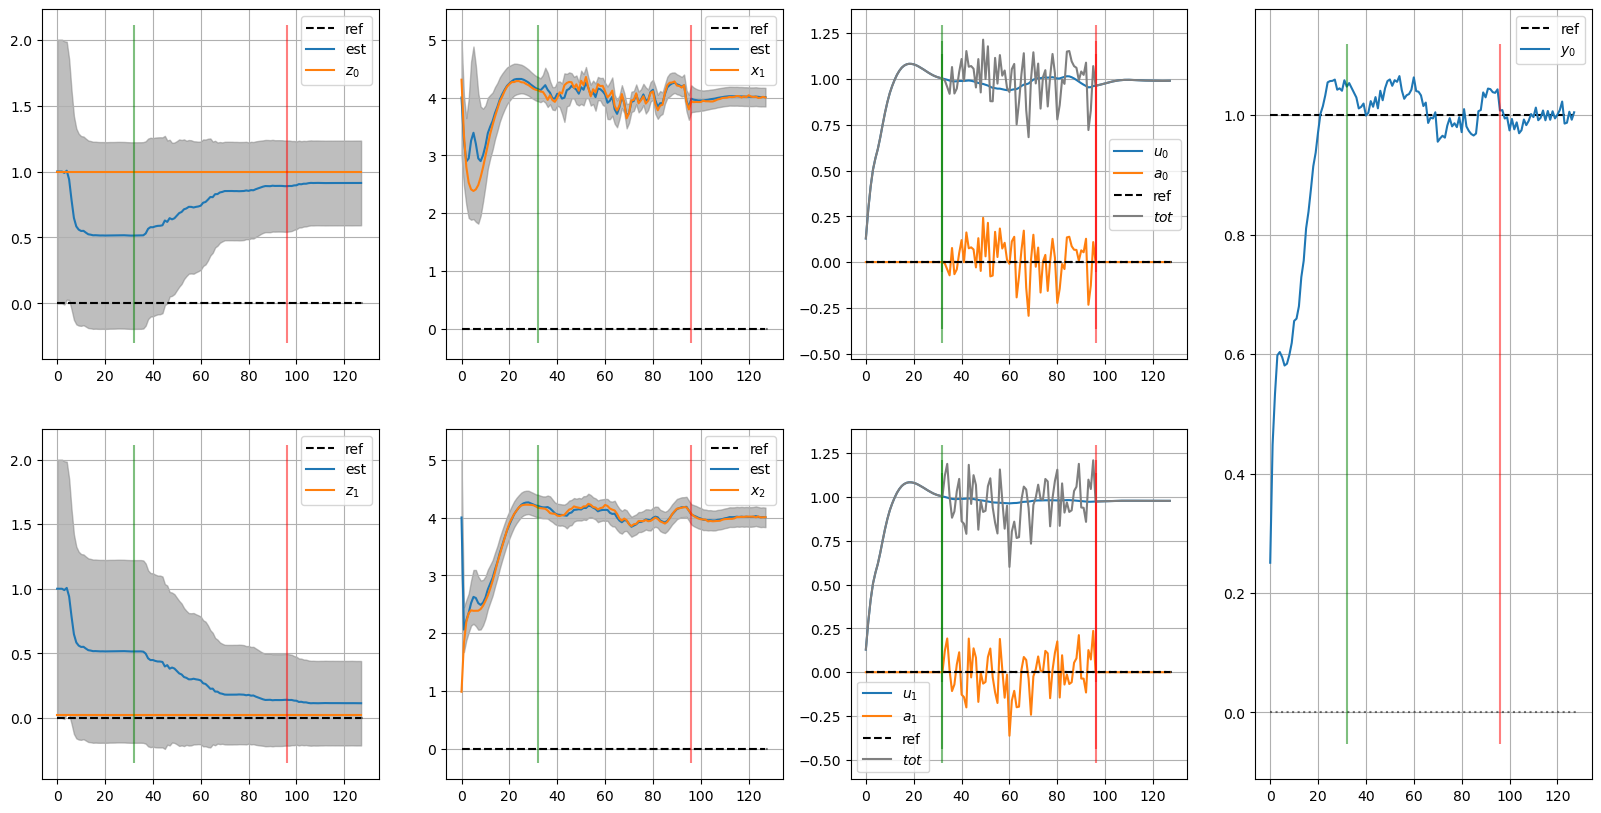

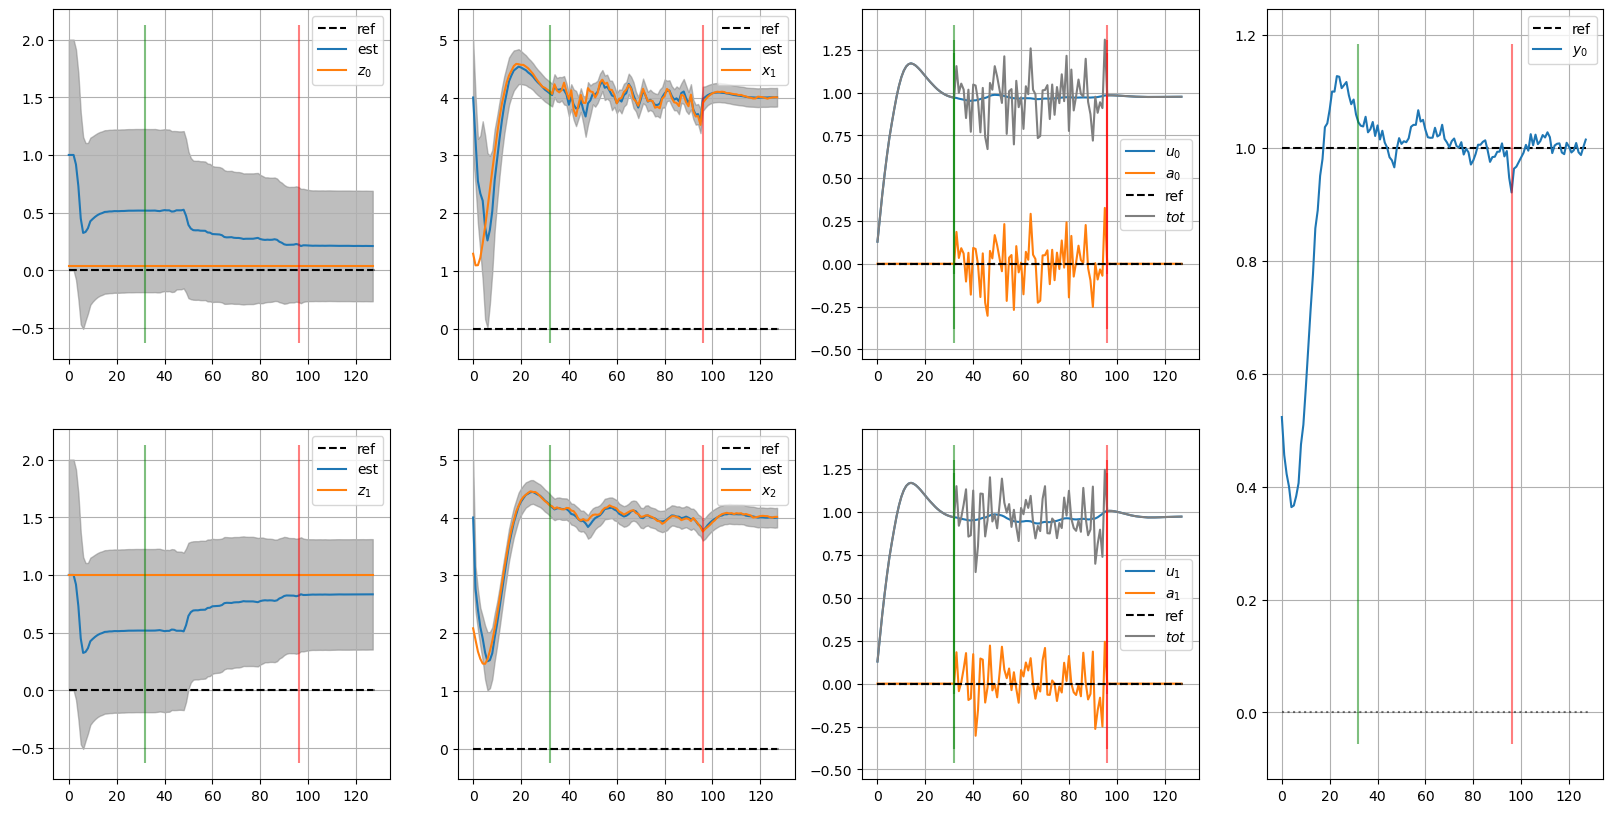

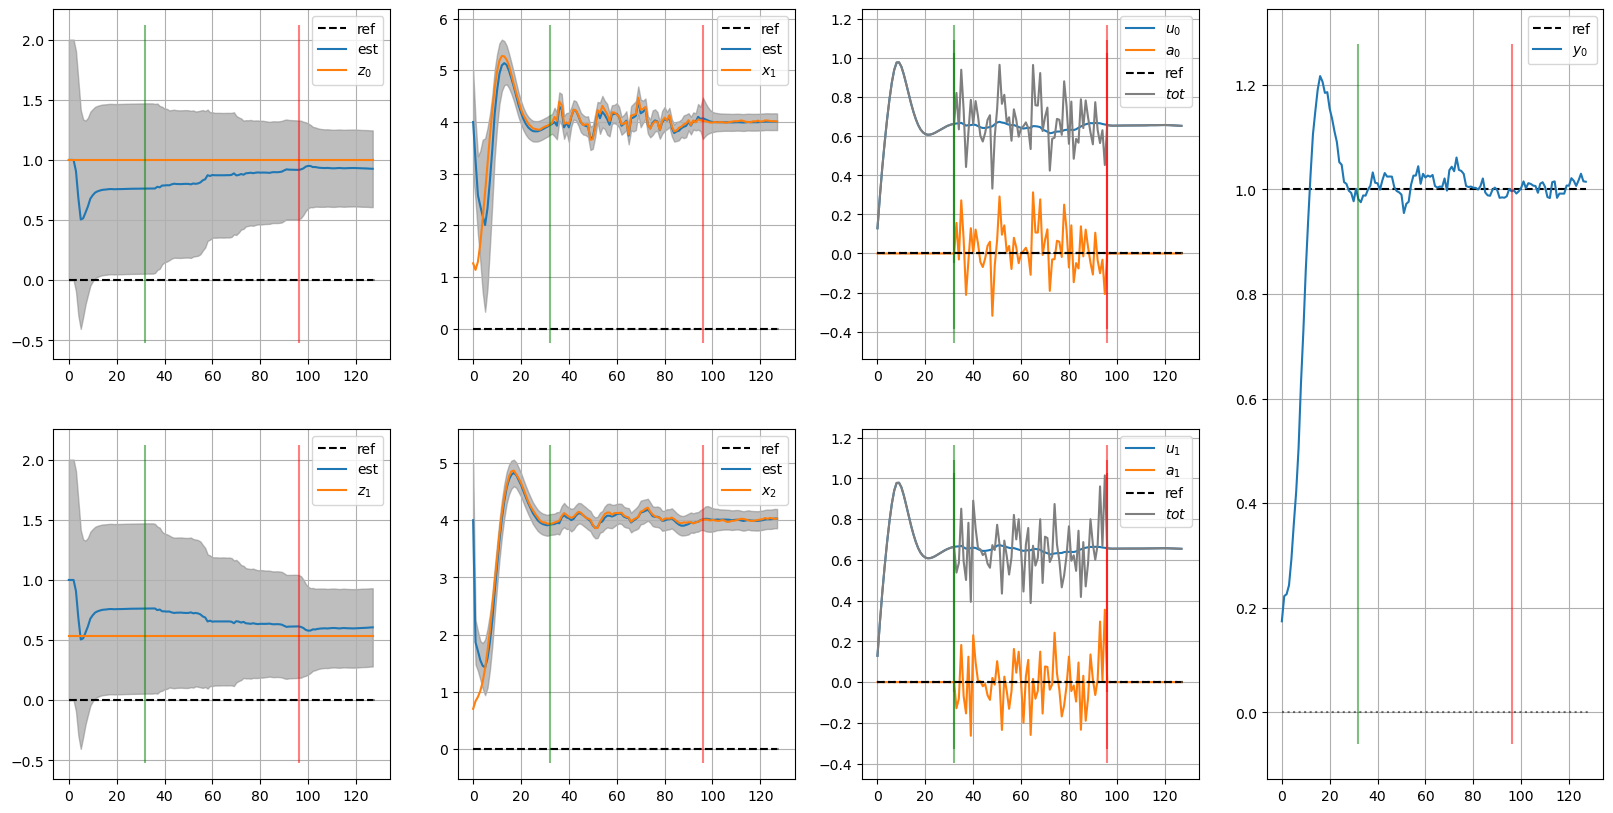

In [5]:
policy = trainer.untrained_policy

costs, rewards = [], []
for i in range(100):
    rollout, out = trainer.env.rollout(policy)    
    R = get_returns(rollout.r, trainer.discount)[0]
    C = get_returns(rollout.c, trainer.discount)[0]
    costs.append(C)
    rewards.append(R)
costs, rewards = jnp.array(costs), jnp.array(rewards)
print(f"Mean return: {jnp.mean(rewards)} +- {jnp.std(rewards)}")
print(f"Mean cost: {jnp.mean(costs)} +- {jnp.std(costs)}")

for i in range(10):
    rollout, out = trainer.env.rollout(policy)    
    trainer.env.render(out)

# Trained Policy

Mean return: -1.5944275792424025 +- 1.1290715734572652
Mean cost: 0.9193647847396744 +- 0.3715338424679897


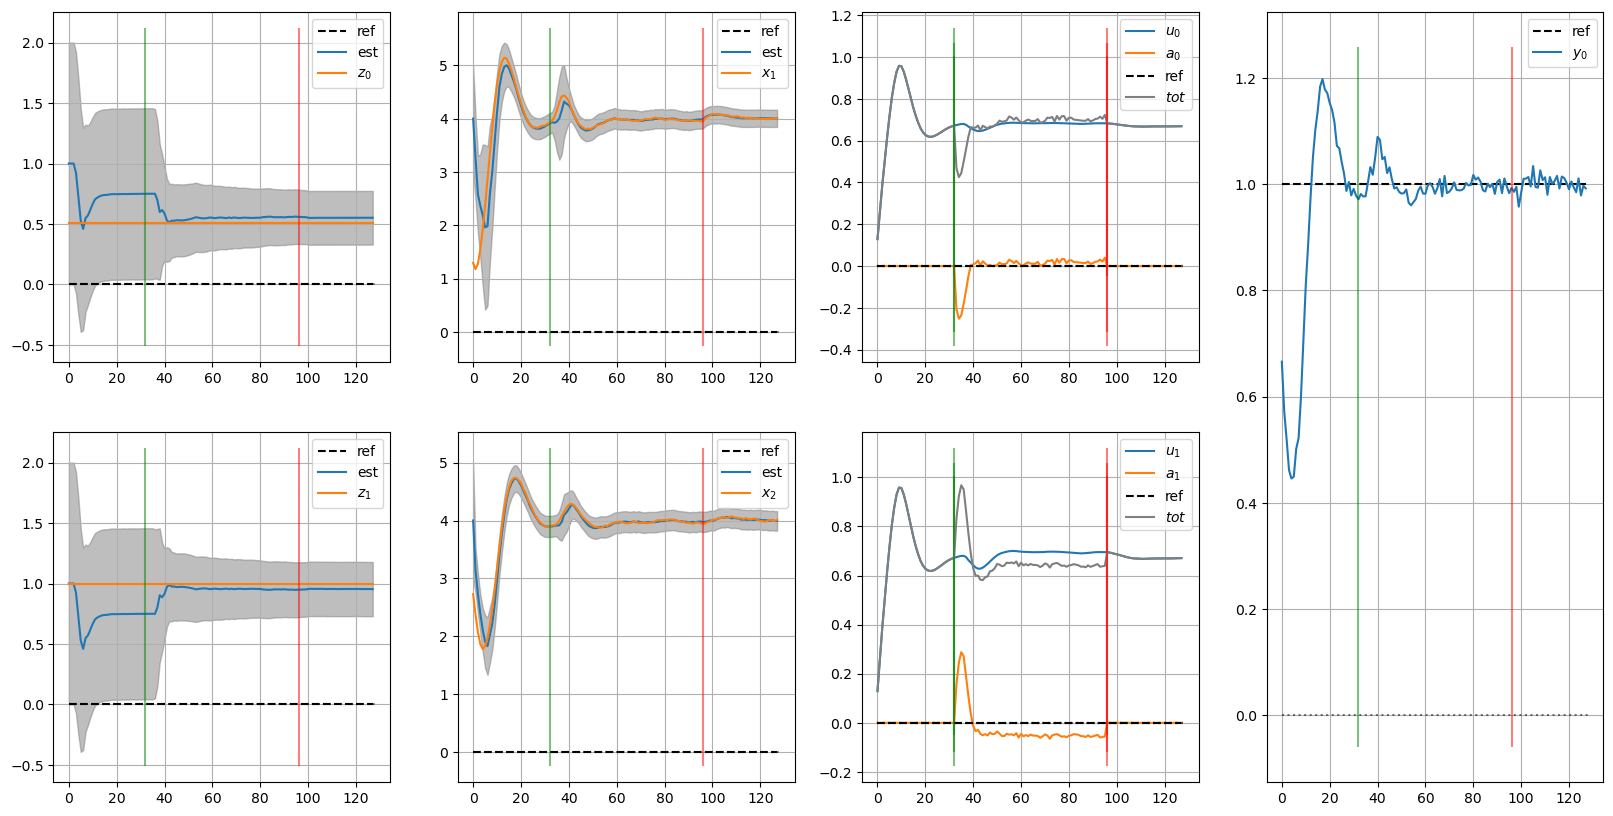

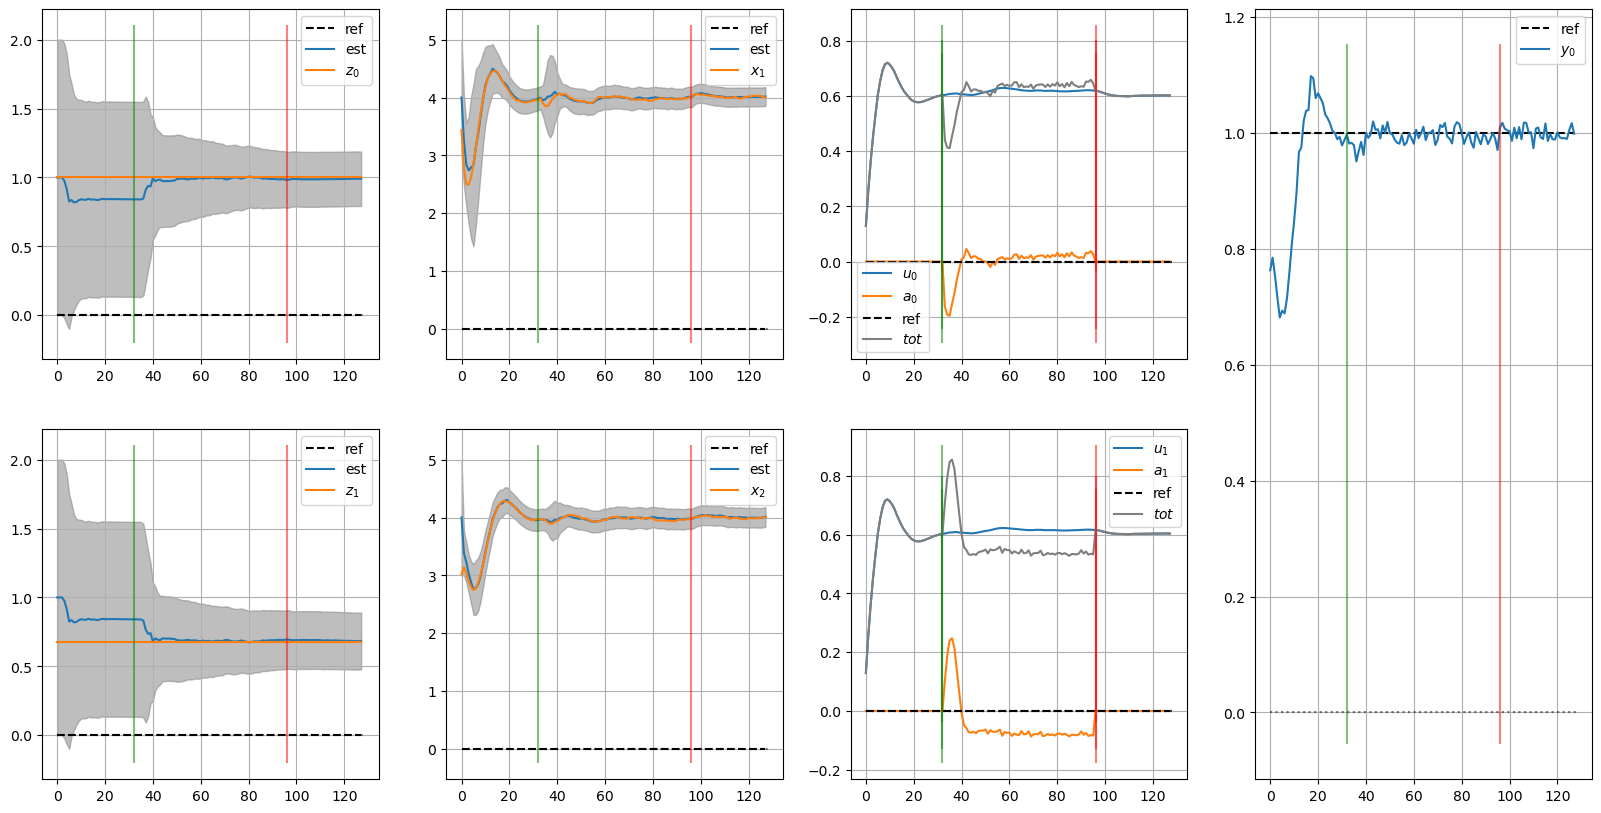

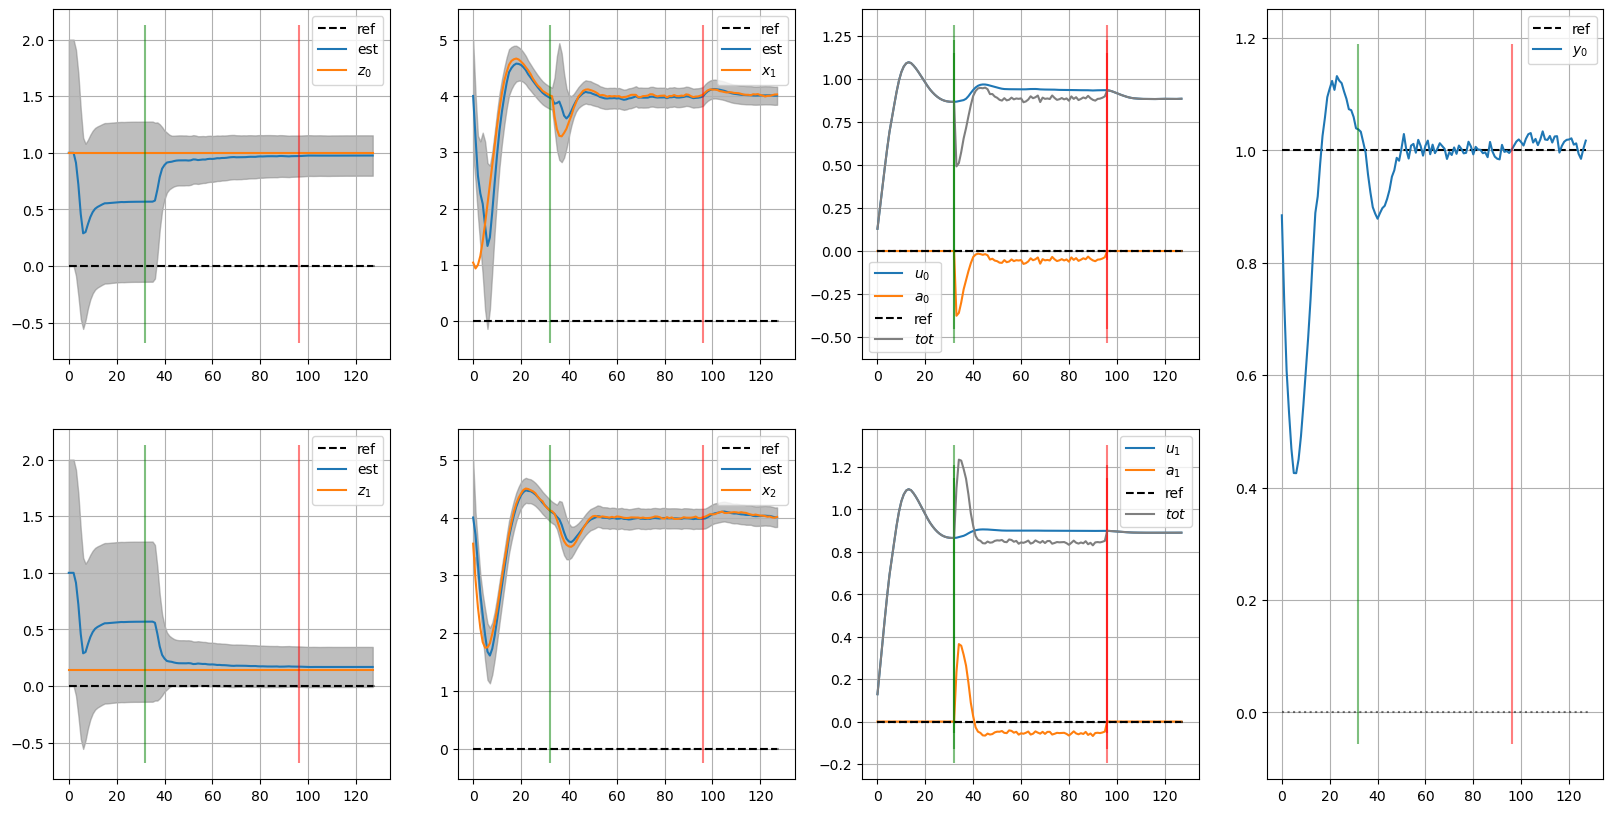

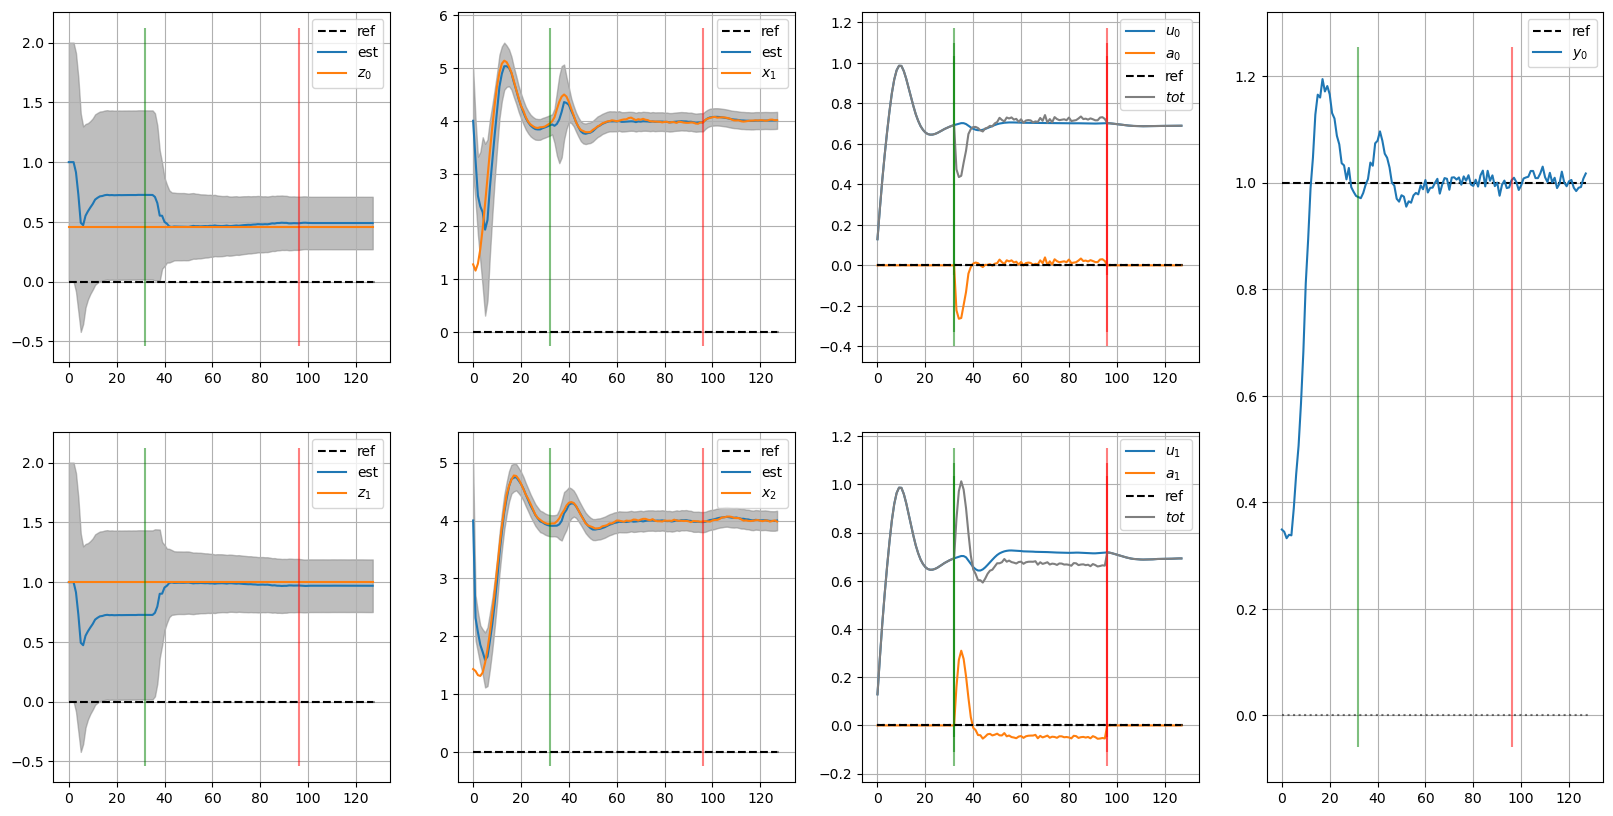

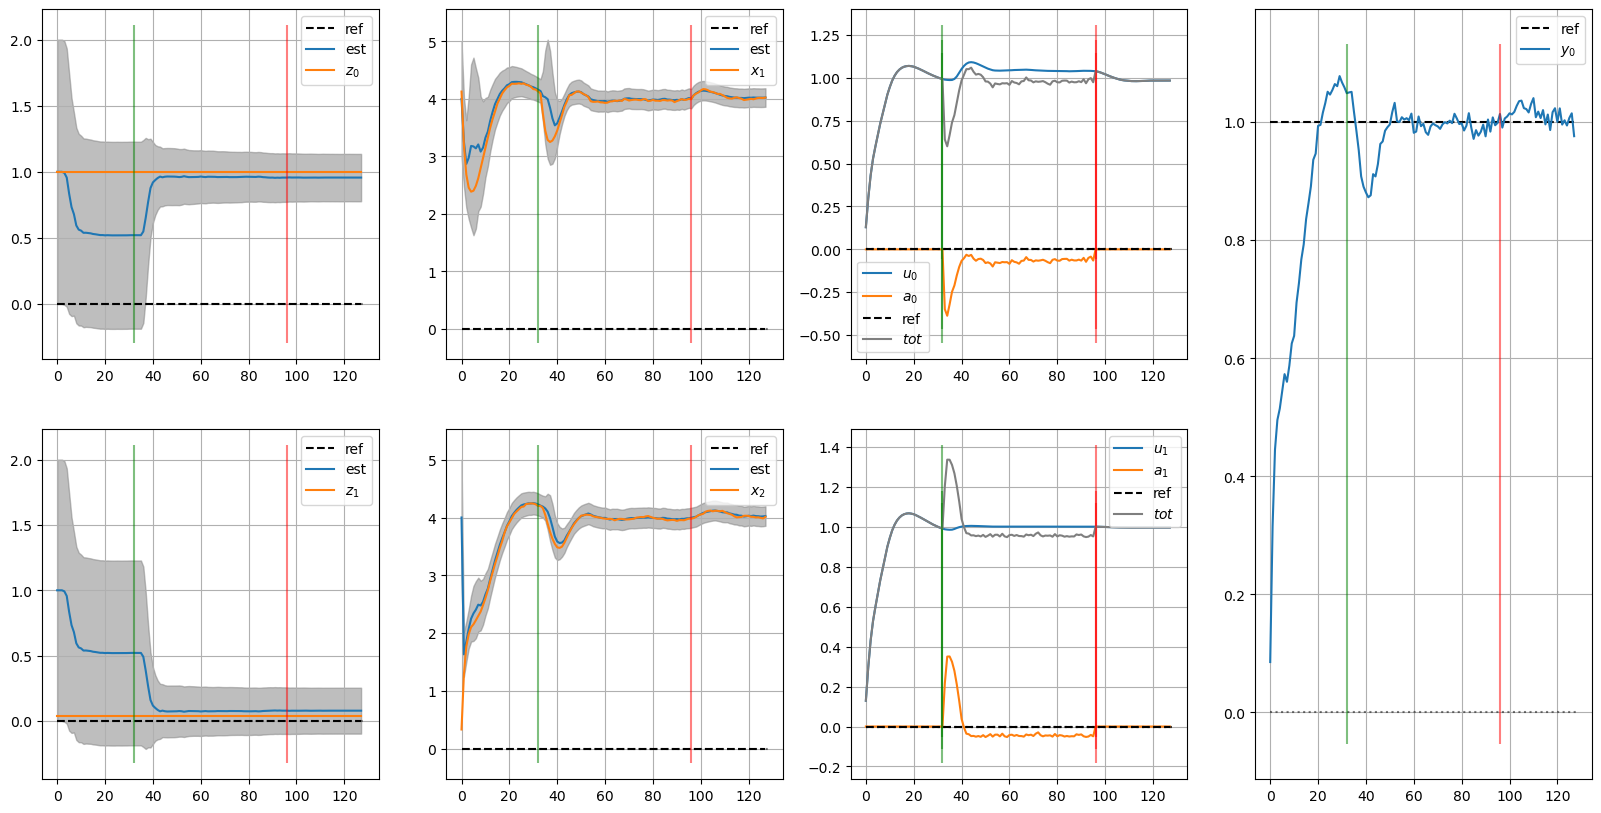

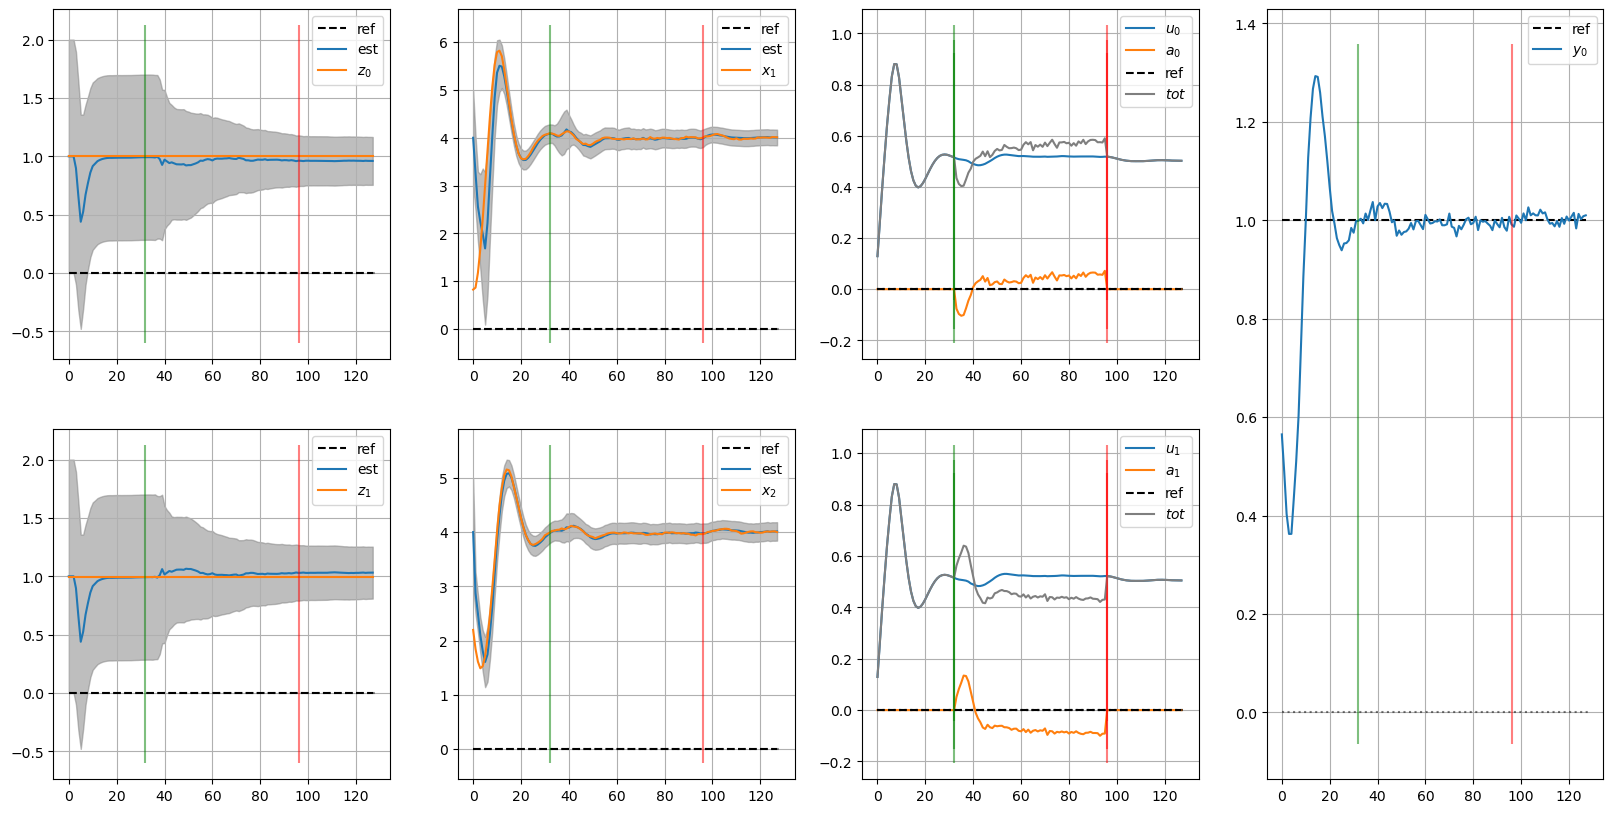

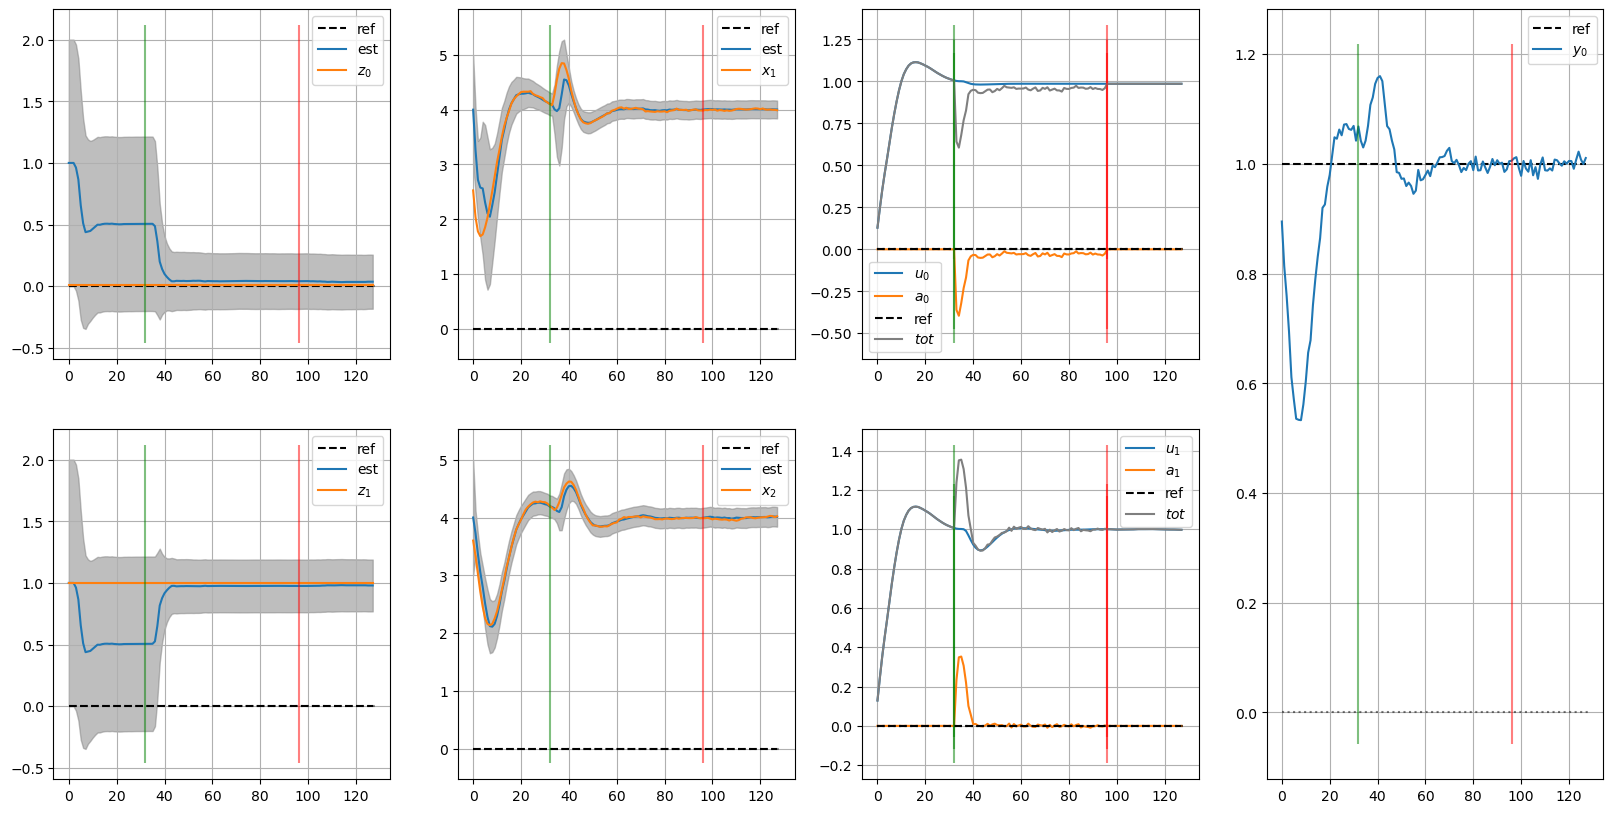

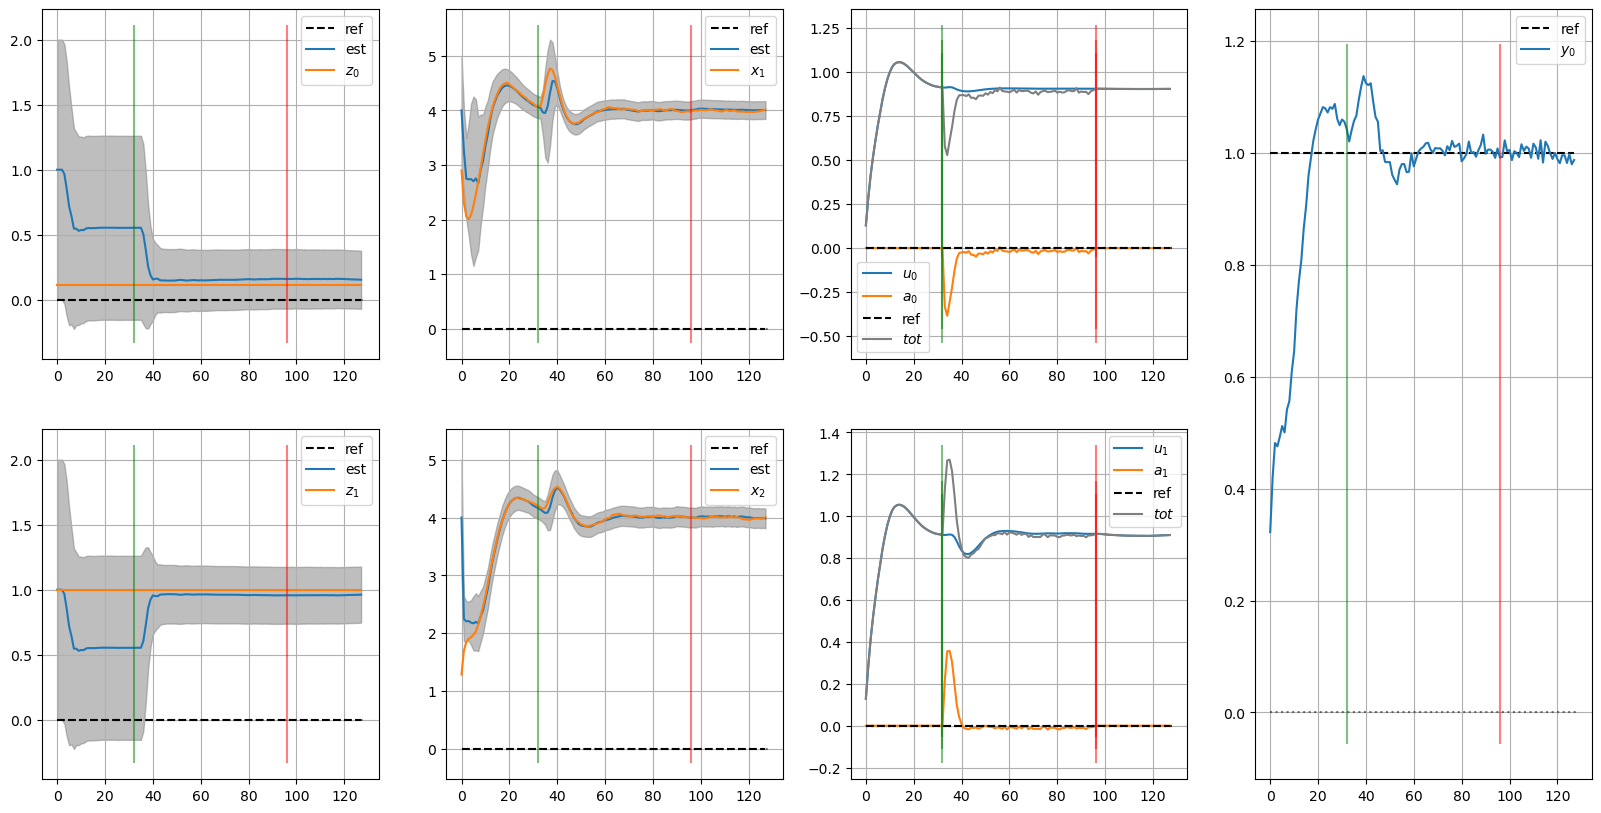

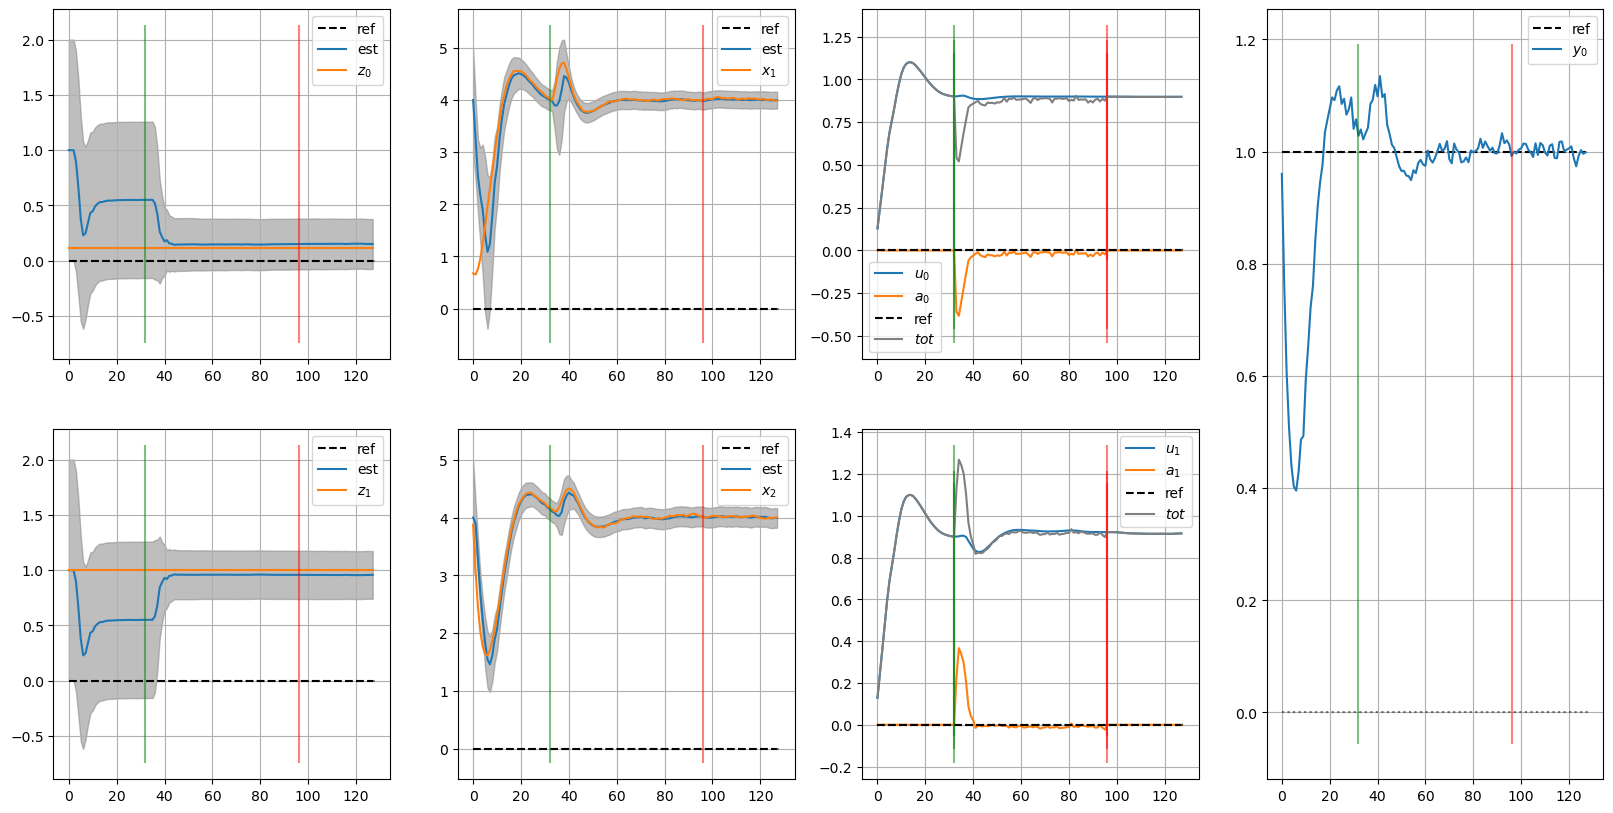

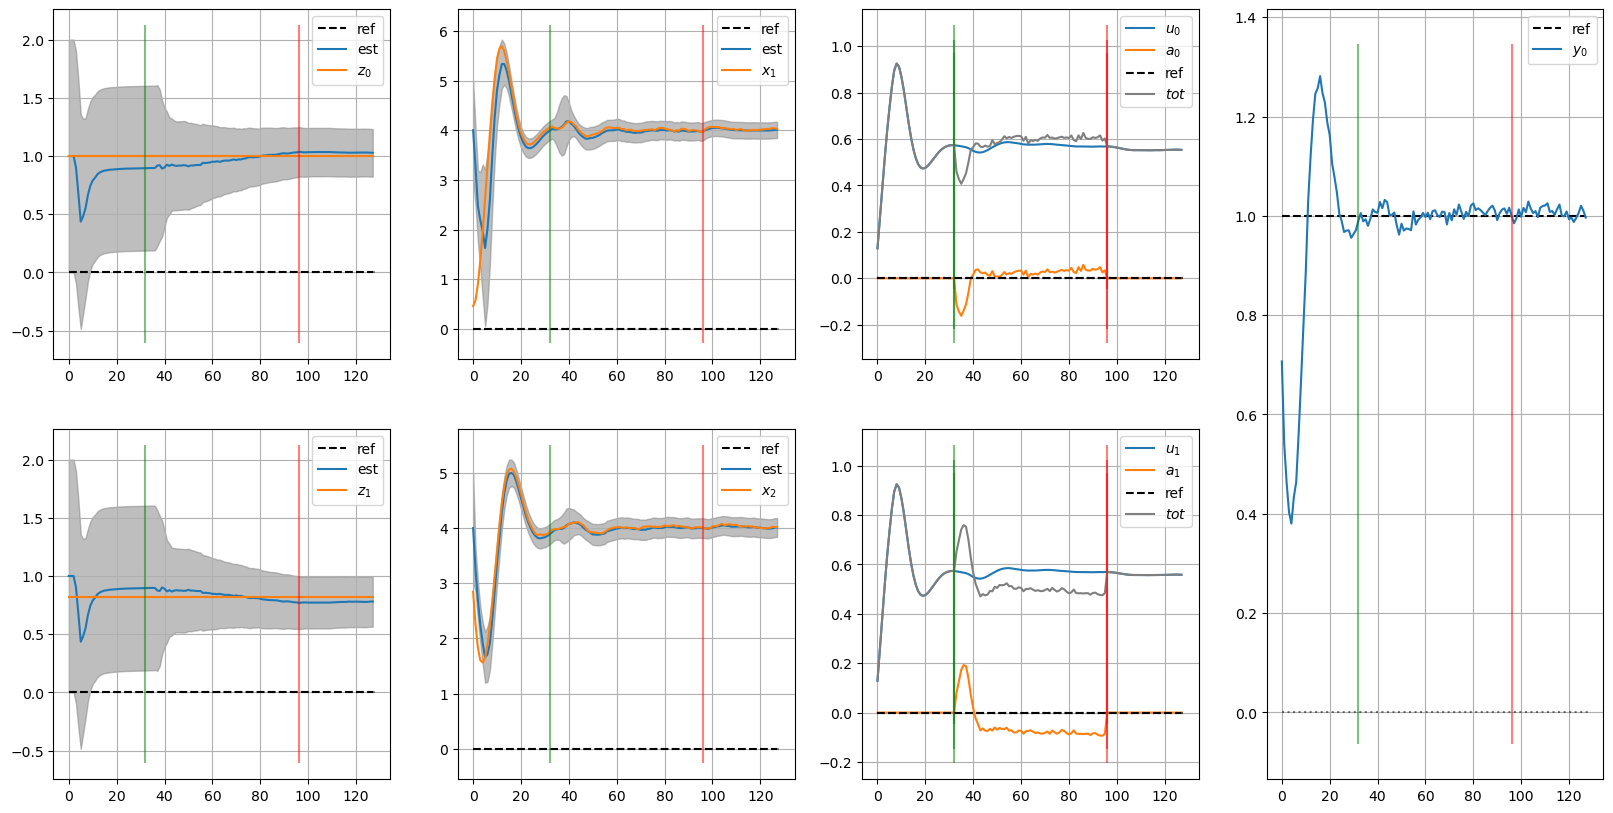

In [6]:
policy = trainer.policy

costs, rewards = [], []
for i in range(100):
    rollout, out = trainer.env.rollout(policy)    
    R = get_returns(rollout.r, trainer.discount)[0]
    C = get_returns(rollout.c, trainer.discount)[0]
    costs.append(C)
    rewards.append(R)
costs, rewards = jnp.array(costs), jnp.array(rewards)
print(f"Mean return: {jnp.mean(rewards)} +- {jnp.std(rewards)}")
print(f"Mean cost: {jnp.mean(costs)} +- {jnp.std(costs)}")

for i in range(10):
    rollout, out = trainer.env.rollout(policy)    
    trainer.env.render(out)

# Deterministic Policy

Mean return: -1.7277496145363374 +- 1.1328057498117863
Mean cost: 0.9978282434605792 +- 0.4167036302339539


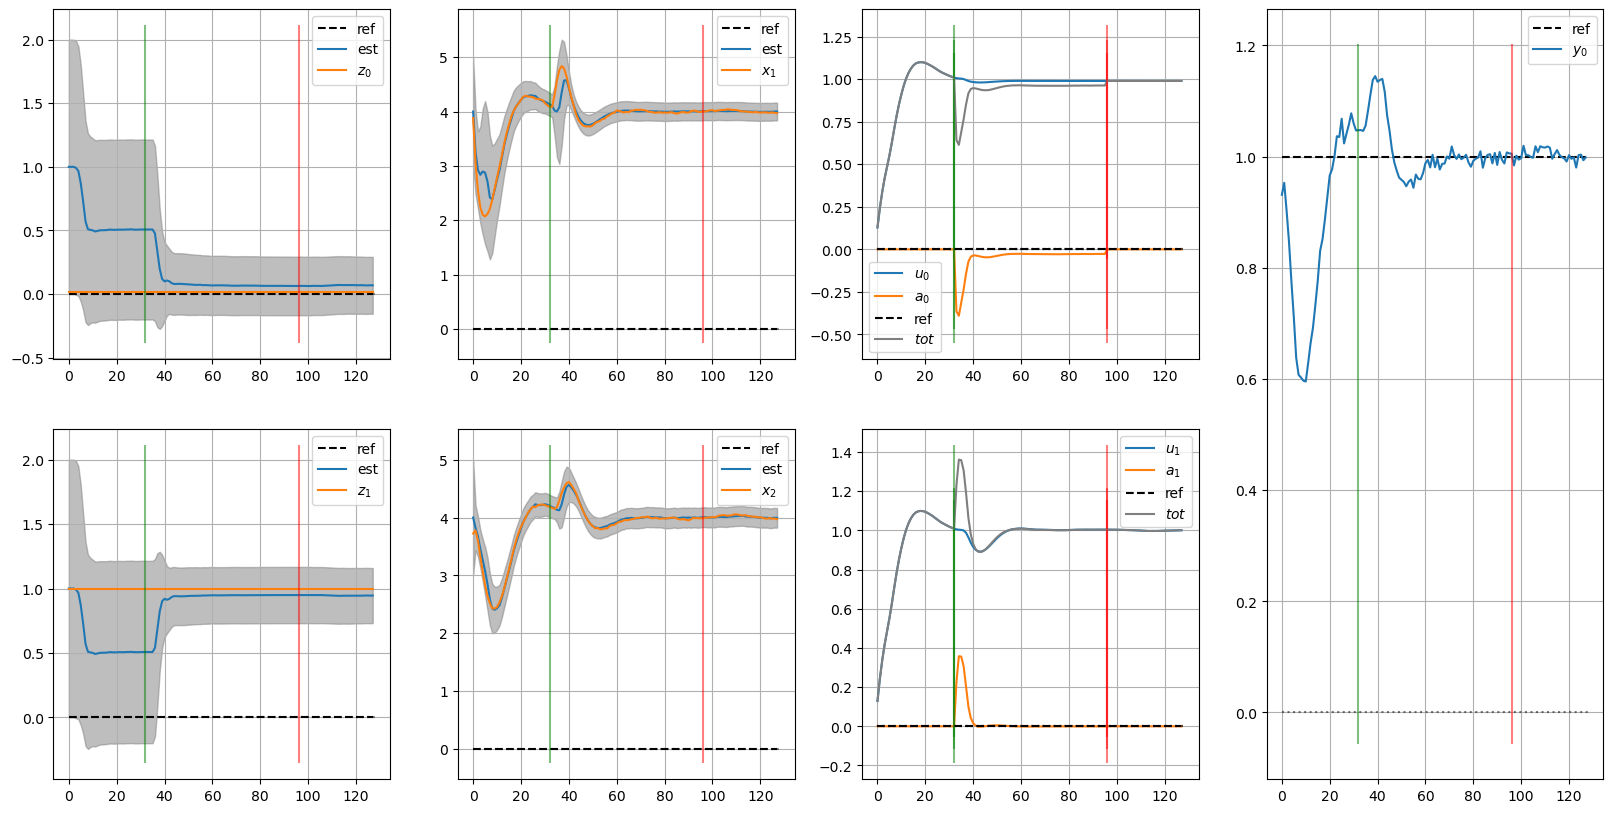

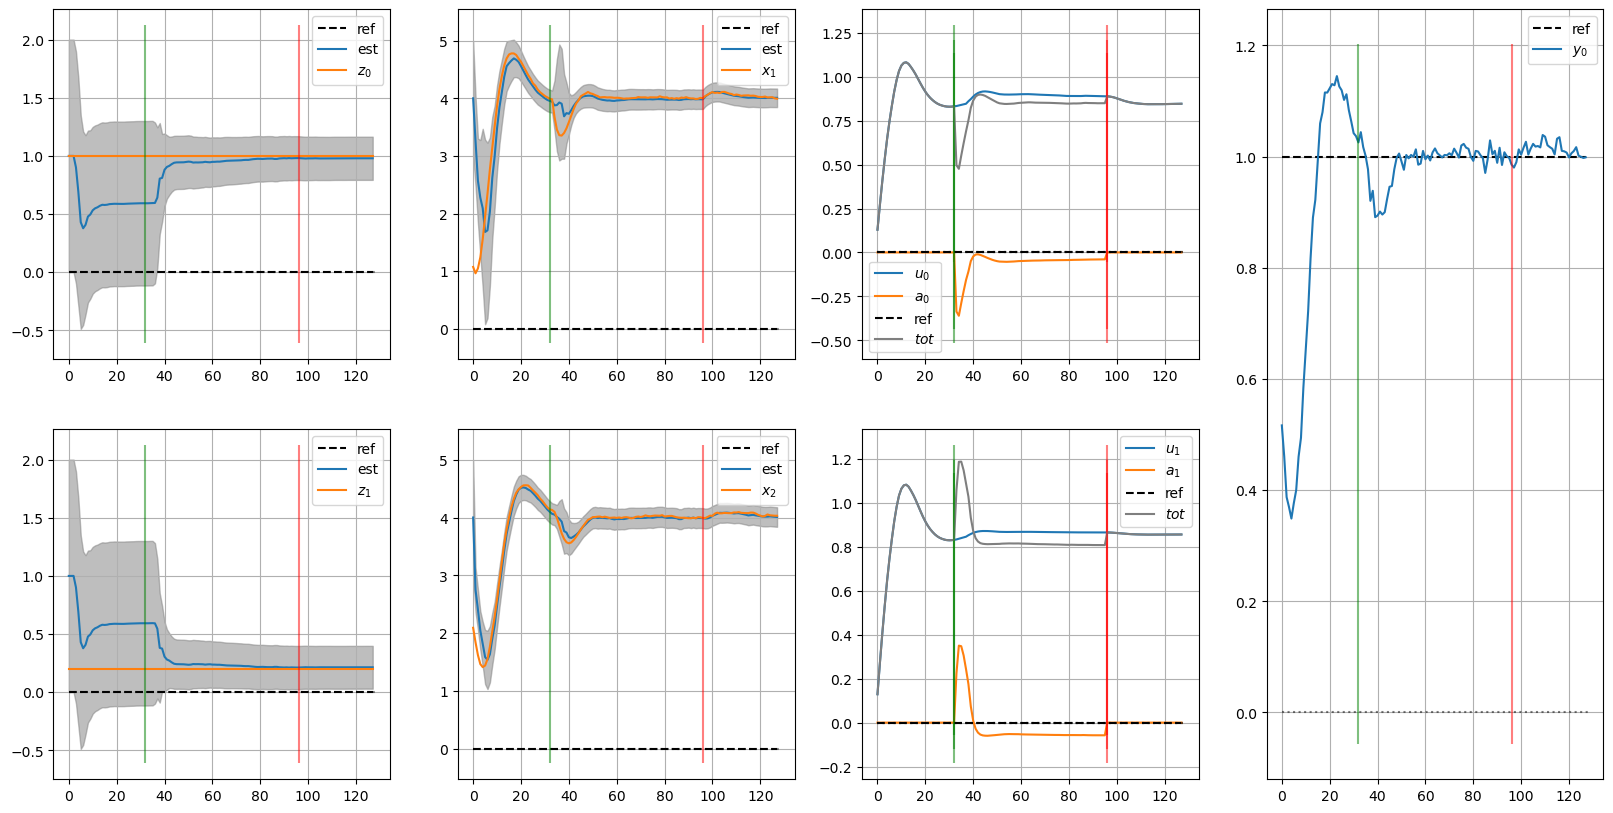

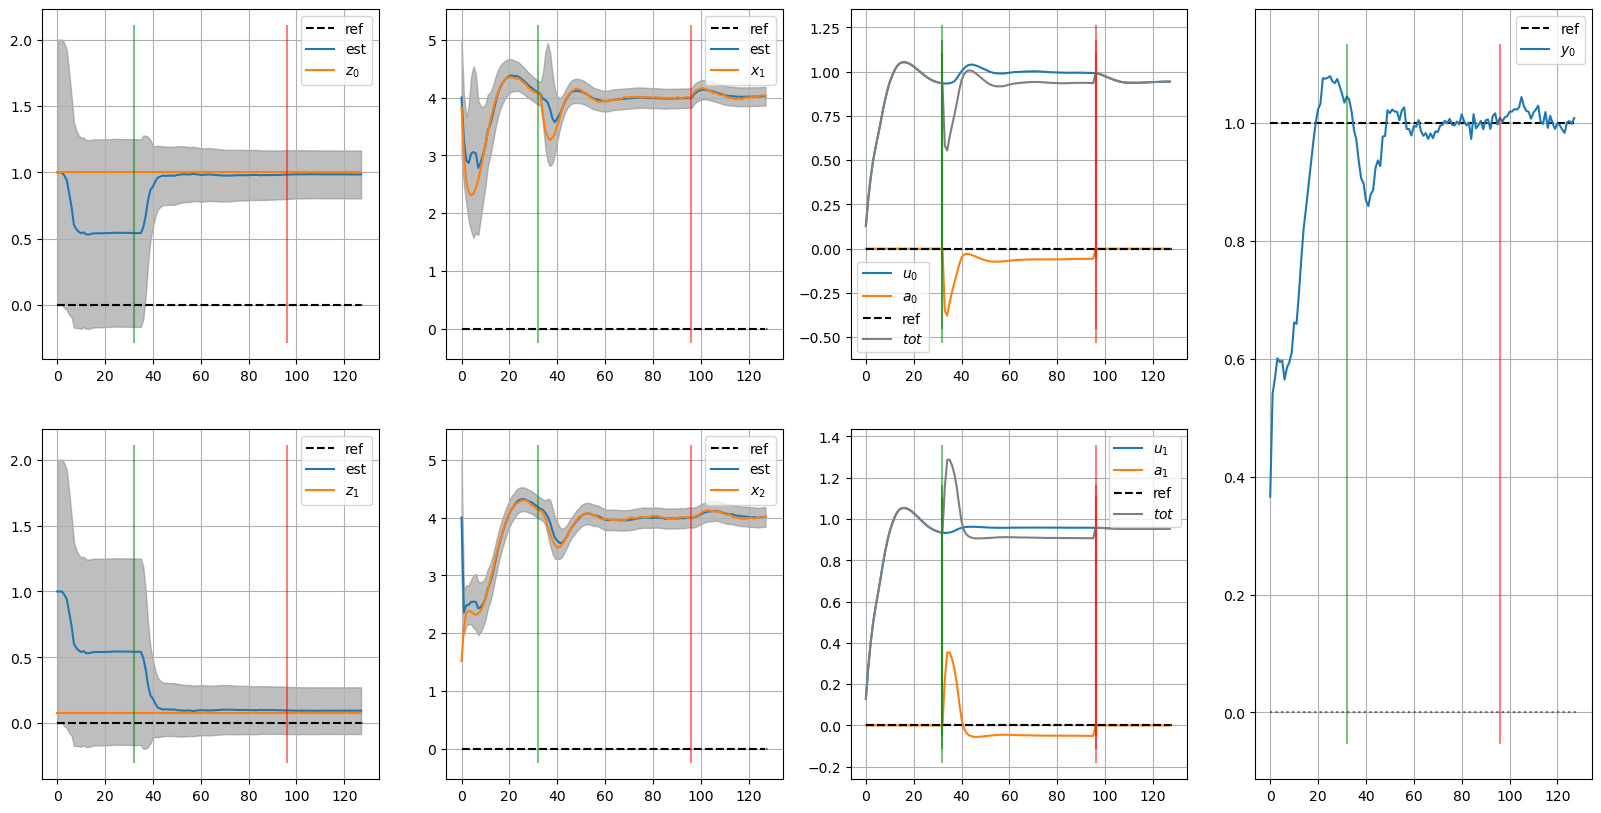

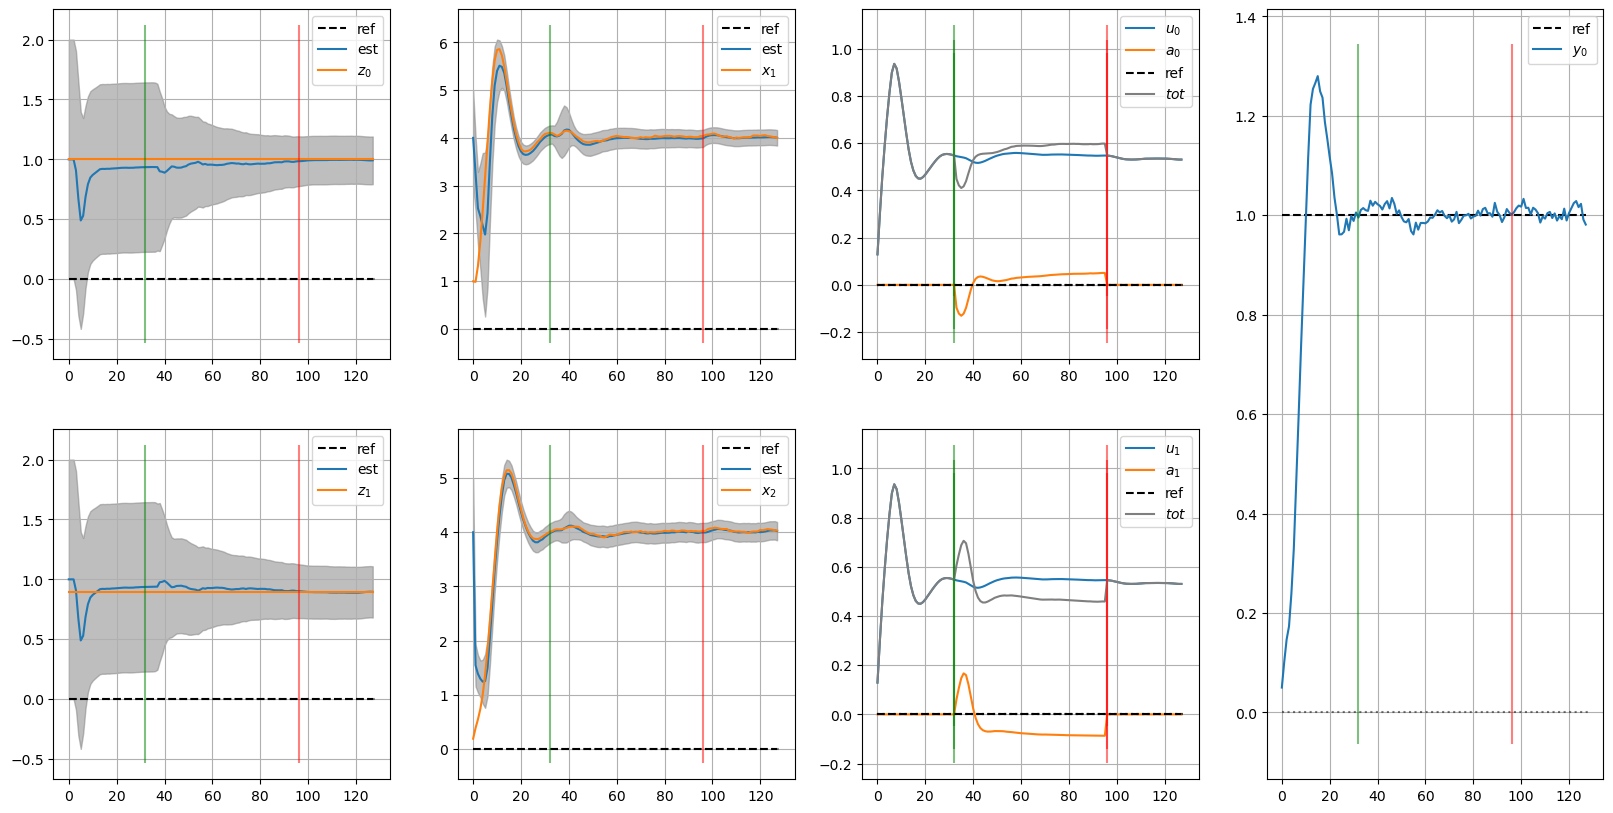

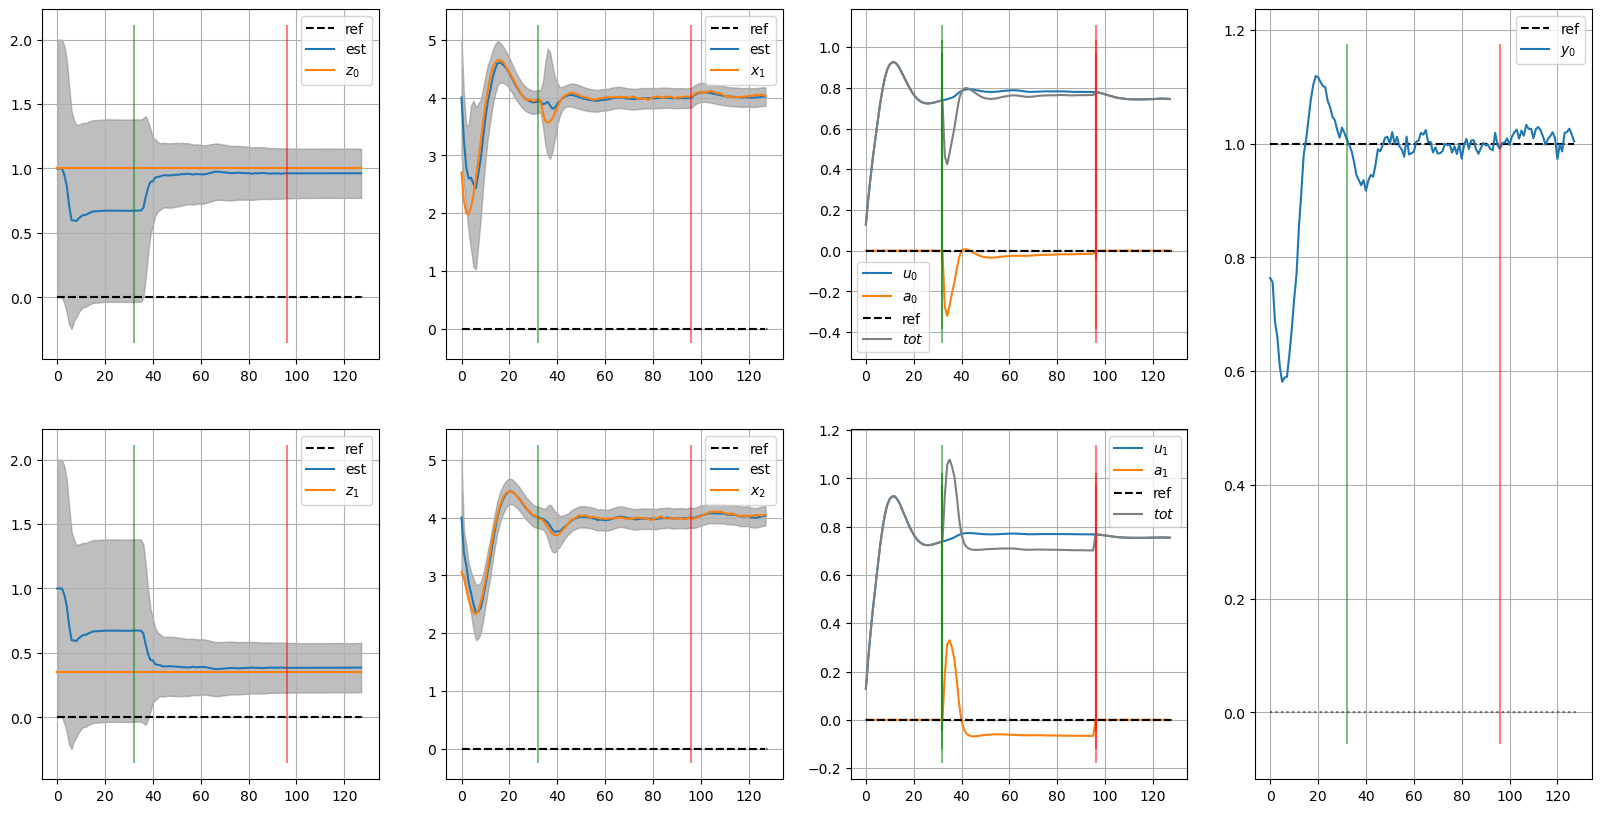

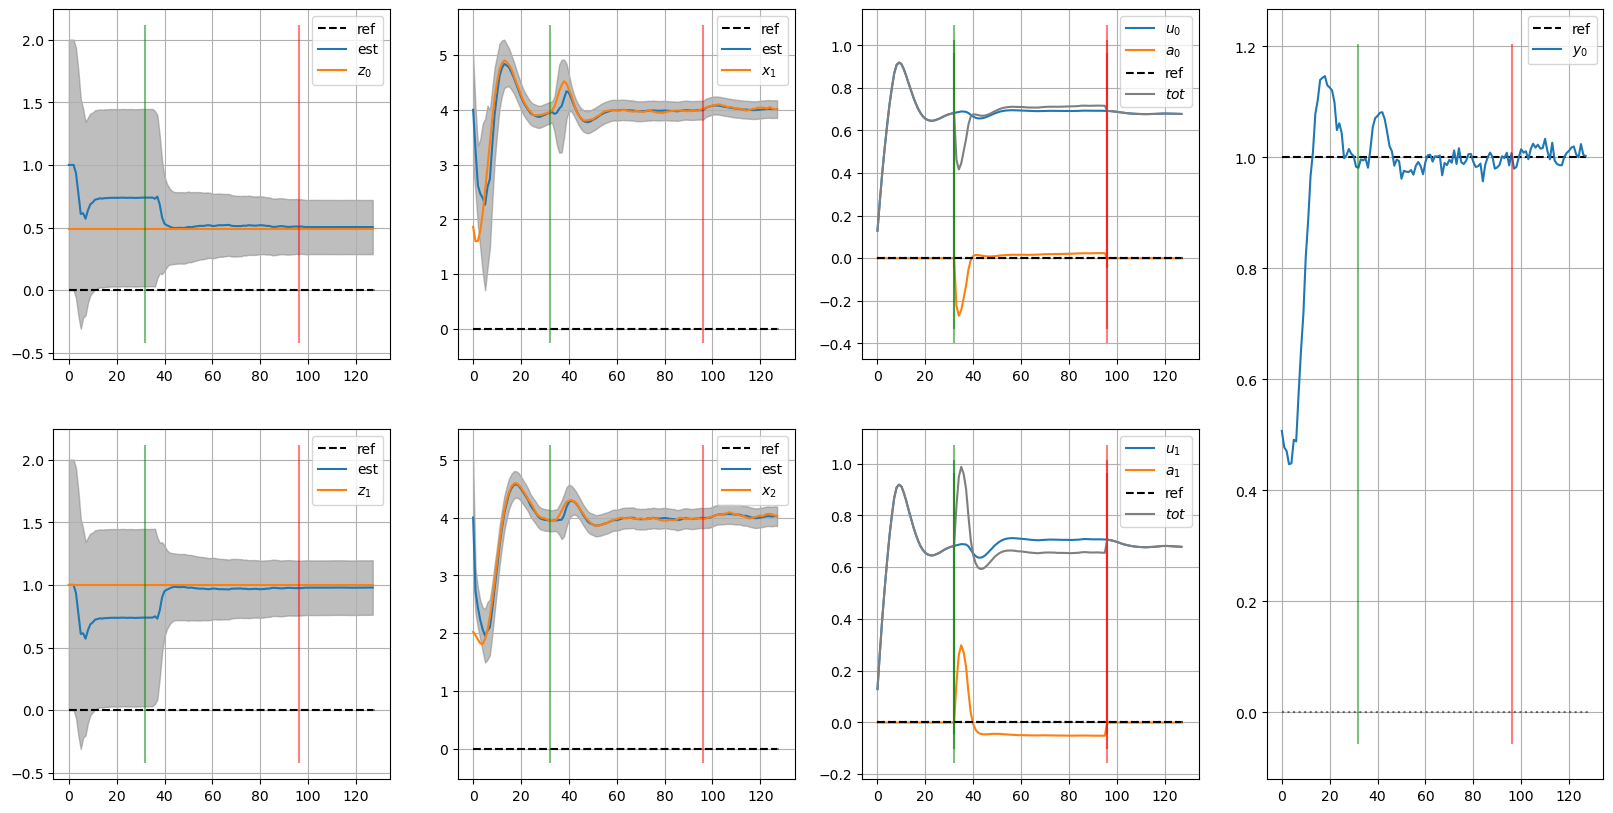

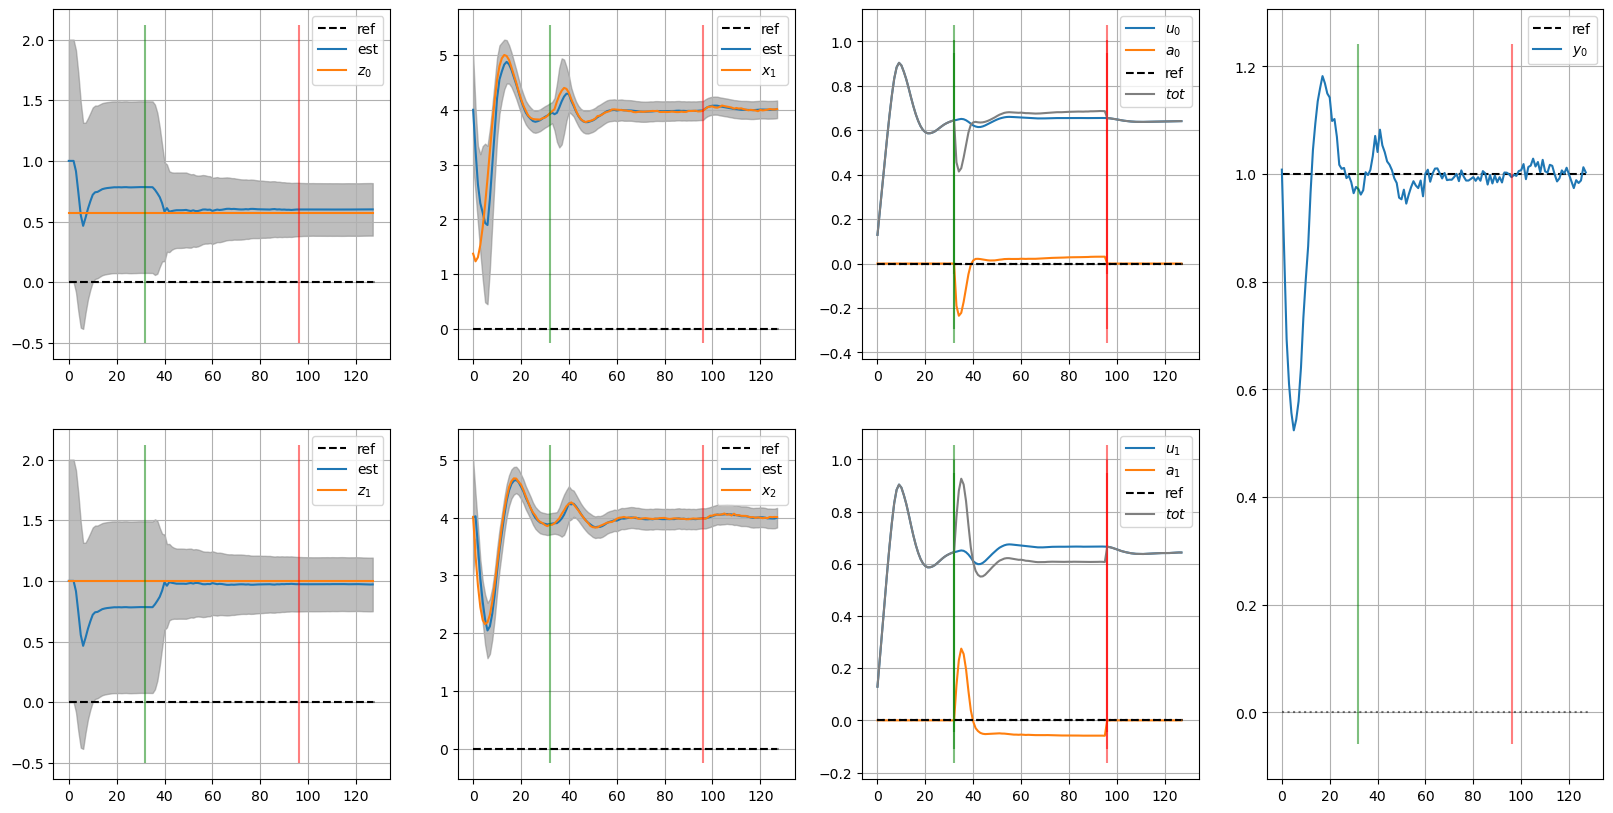

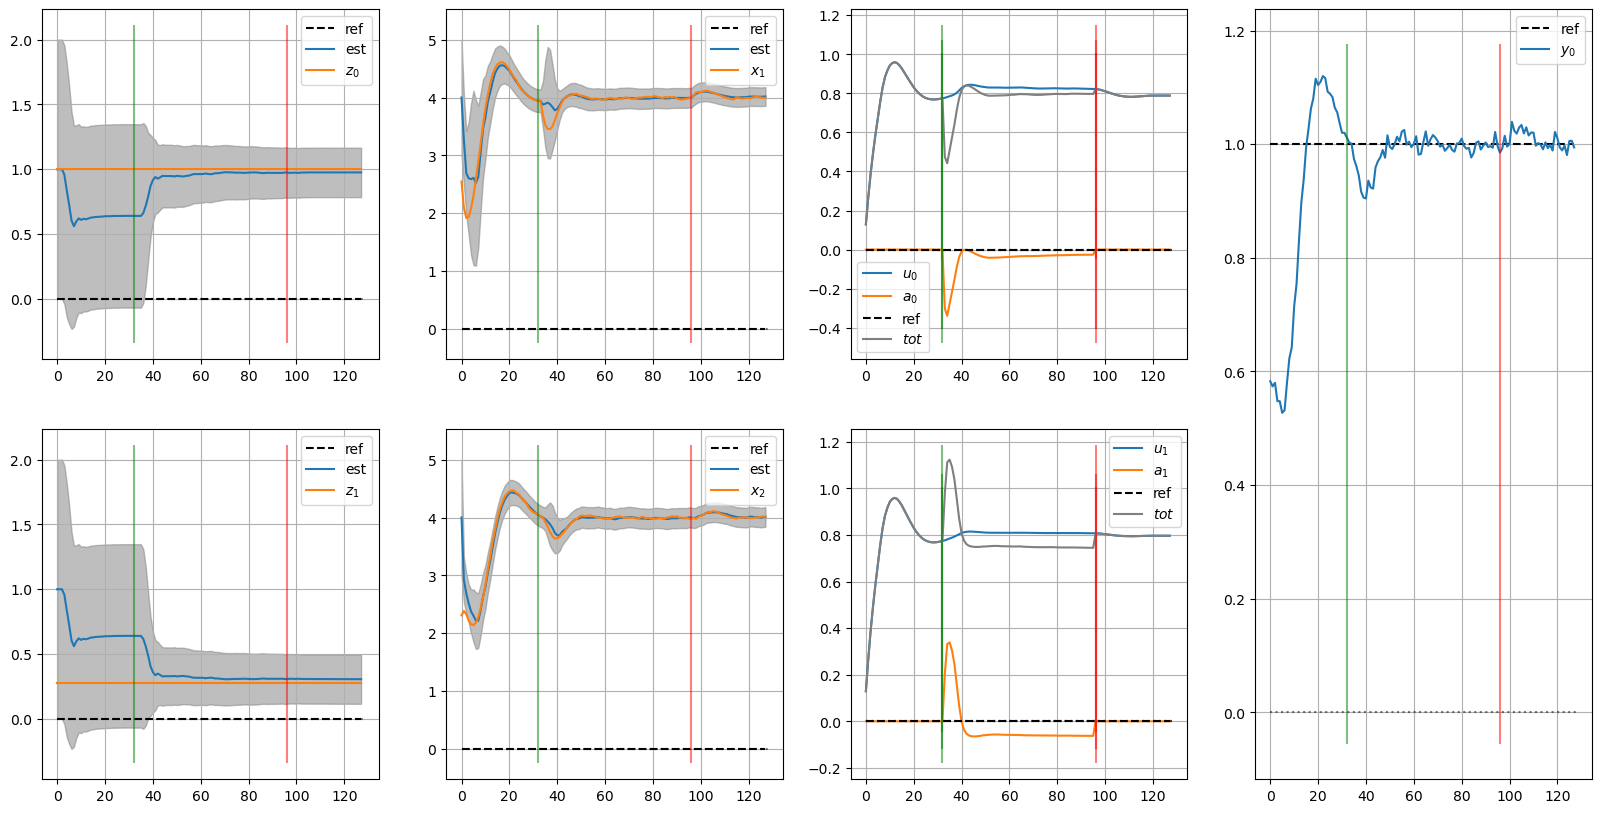

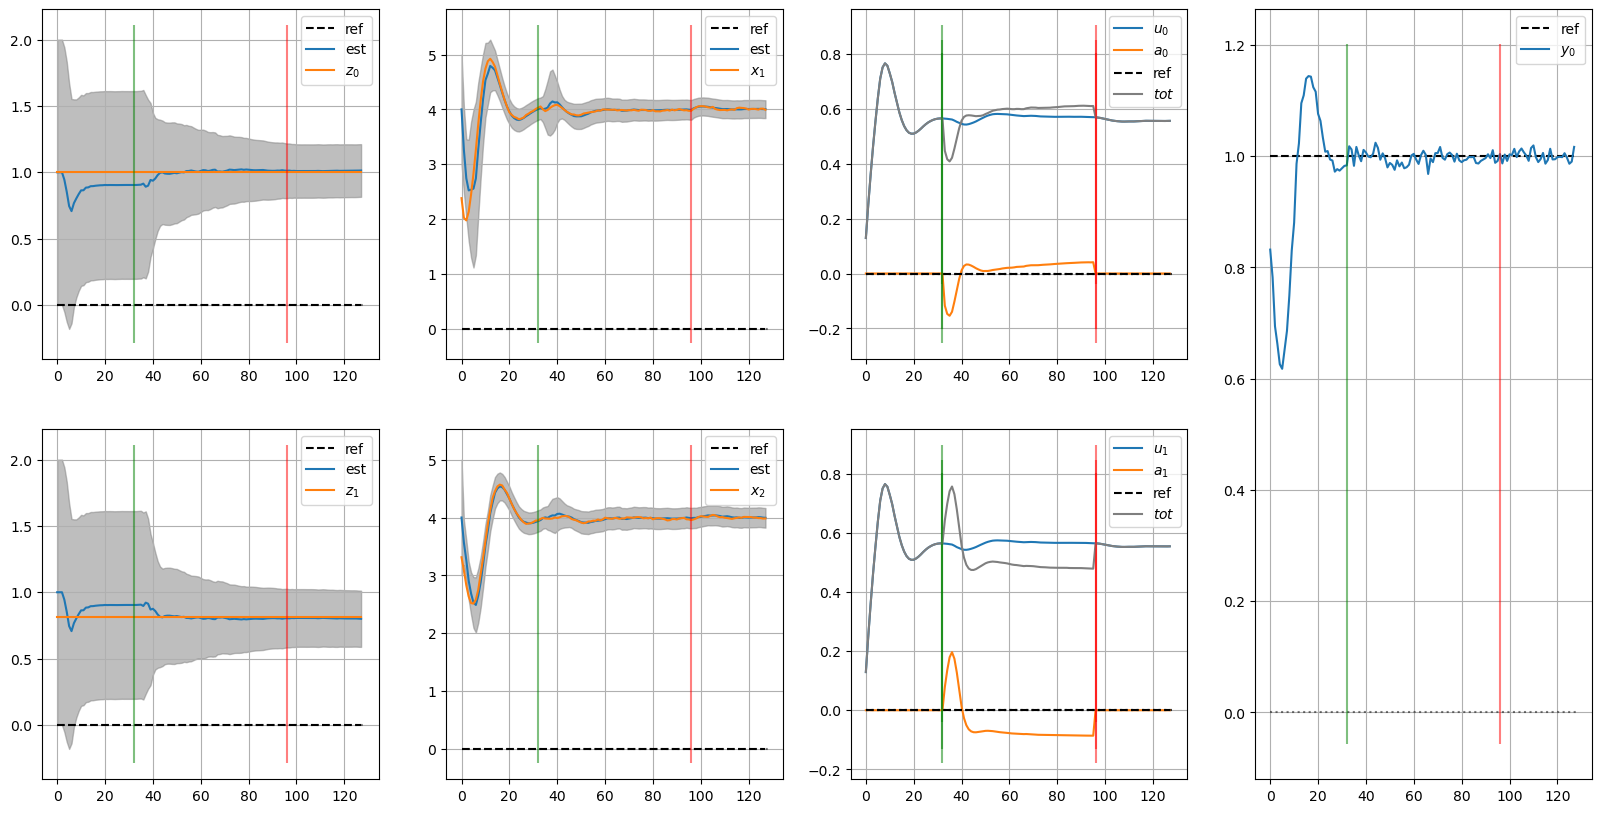

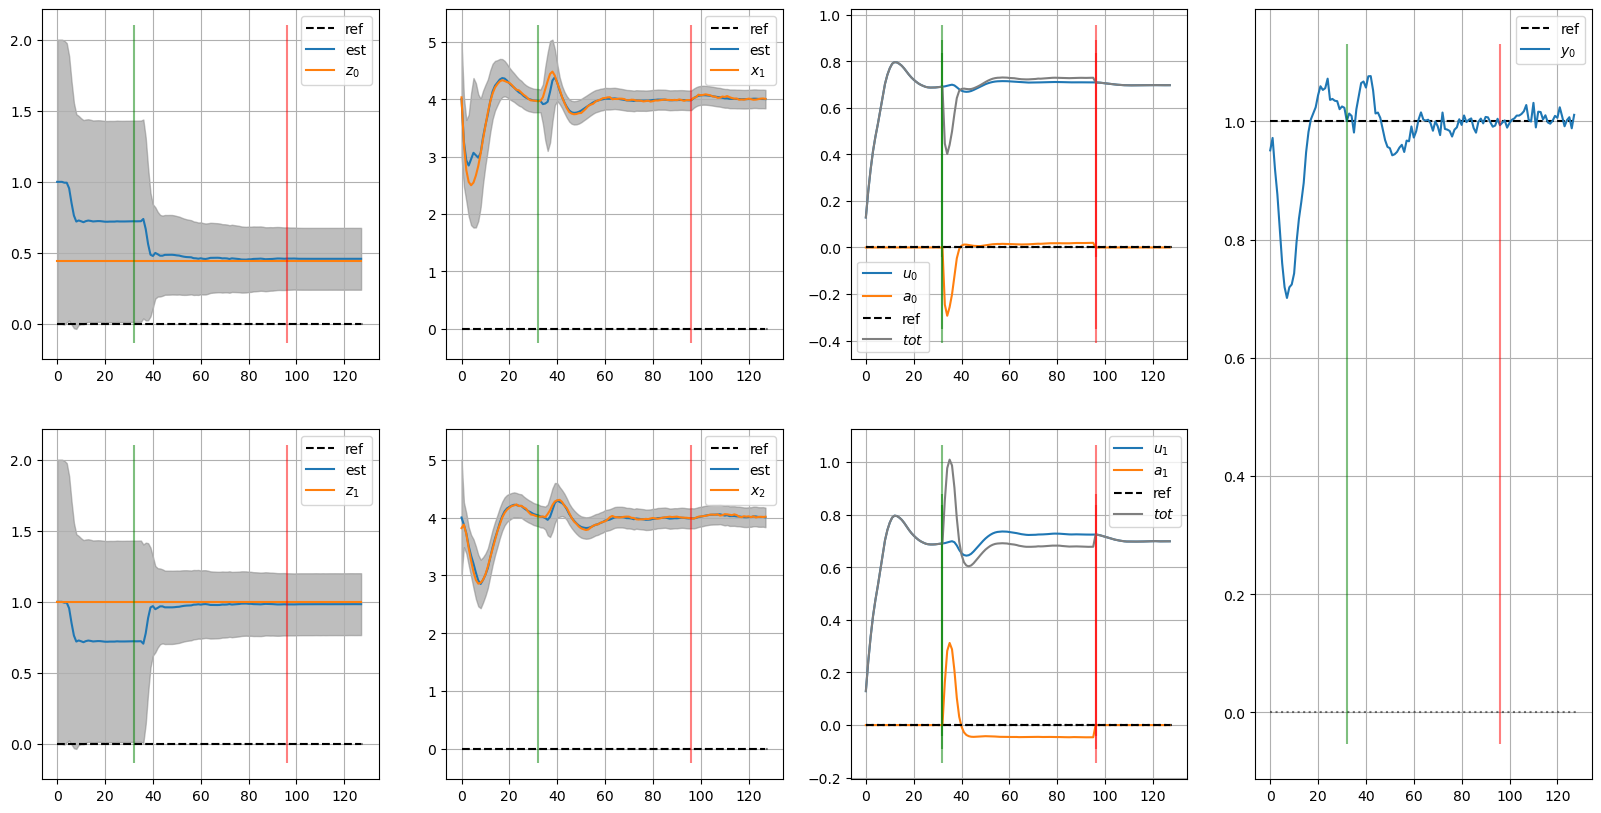

In [7]:
policy = nnx.clone(trainer.policy)
policy.std *= 1e-20

costs, rewards = [], []
for i in range(100):
    rollout, out = trainer.env.rollout(policy)    
    R = get_returns(rollout.r, trainer.discount)[0]
    C = get_returns(rollout.c, trainer.discount)[0]
    costs.append(C)
    rewards.append(R)
costs, rewards = jnp.array(costs), jnp.array(rewards)
print(f"Mean return: {jnp.mean(rewards)} +- {jnp.std(rewards)}")
print(f"Mean cost: {jnp.mean(costs)} +- {jnp.std(costs)}")

for i in range(10):
    rollout, out = trainer.env.rollout(policy)    
    trainer.env.render(out)